# Inception — Sleep-Stage Classification: EDA

Exploratory analysis of the `inception/` dataset: load the data, inspect shapes/heads, check class balance and missingness, and visualise how key physiological features separate the four sleep stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "inception"
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

TARGET = "sleep_stage"
features = [c for c in train.columns if c not in ("id", TARGET)]
print(f"{len(features)} feature columns")

21 feature columns


## Shape and head of each file

In [2]:
for name, df in [("train", train), ("test", test), ("sample_submission", sample_submission)]:
    print(f"{name}: shape = {df.shape}")
    display(df.head())

train: shape = (9000, 23)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


test: shape = (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index
0,9000,4.24709,2.24352,0.82429,-2.17291,1.43316,-2.25920,1.06346,-1.45614,2.30776,-1.92589,0.47695,-0.01680,-4.50347,-1.21023,-2.24473,2.58896,-5.02117,1.77028,-0.62667,3.20780,-0.14174
1,9001,-2.37302,-5.60293,-3.69060,3.60306,1.18660,-3.03282,-4.45284,0.75015,-1.12286,0.29501,-4.23371,-1.93622,-0.98139,-2.24492,-0.91085,-0.86407,5.24594,-0.40843,2.94304,-3.56779,-0.51467
2,9002,-2.82645,3.41445,2.83025,-0.10690,2.96436,2.80361,-1.56655,-2.70384,2.51496,2.24417,1.76296,-1.40091,-0.00776,4.46619,1.81697,-0.41014,0.33340,4.12864,-1.09006,-2.27858,NaN
3,9003,0.36455,-2.23034,-7.35006,2.78573,-2.35427,-3.43257,-1.45572,3.87522,0.31208,0.18739,-3.80453,-0.23742,-2.65285,-2.54412,-1.82521,0.81569,2.25889,-1.27536,0.49894,-2.48382,0.42914
4,9004,0.36140,-0.27564,5.62351,1.37929,-1.27907,-1.43678,0.11626,-2.40858,-3.44948,-4.30699,1.34741,-1.71887,4.85418,-1.04809,3.73200,-0.28232,-0.04884,-3.16412,2.44813,-0.43193,-0.62831


sample_submission: shape = (5000, 2)


,id,sleep_stage
0,9000,1
1,9001,1
2,9002,1
3,9003,1
4,9004,1


## Class balance of `sleep_stage`

             count  proportion
sleep_stage                   
0             2001      0.2223
1             2442      0.2713
2             2237      0.2486
3             2320      0.2578


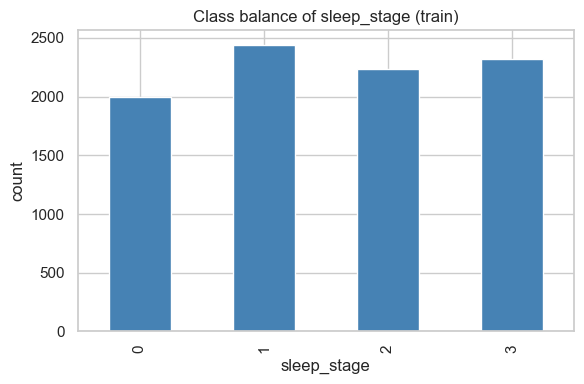

In [3]:
counts = train[TARGET].value_counts().sort_index()
props = train[TARGET].value_counts(normalize=True).sort_index()
print(pd.DataFrame({"count": counts, "proportion": props.round(4)}))

ax = counts.plot(kind="bar", color="steelblue", figsize=(6, 4))
ax.set_xlabel("sleep_stage")
ax.set_ylabel("count")
ax.set_title("Class balance of sleep_stage (train)")
plt.tight_layout()
plt.show()

## Share of missing values per column

In [4]:
missing = pd.DataFrame({
    "train_missing_share": train.isna().mean(),
    "test_missing_share": test.reindex(columns=train.columns).isna().mean(),
}).round(4)
print(missing)
print(f"\nTotal missing cells -> train: {int(train.isna().sum().sum())}, test: {int(test.isna().sum().sum())}")

                         train_missing_share  test_missing_share
id                                    0.0000              0.0000
eeg_delta_power                       0.0000              0.0000
eeg_theta_power                       0.0000              0.0000
eeg_alpha_power                       0.0000              0.0000
eeg_sigma_power                       0.0000              0.0000
eeg_beta_power                        0.0000              0.0000
eeg_gamma_power                       0.0000              0.0000
eeg_slow_osc_power                    0.0000              0.0000
eeg_spectral_entropy                  0.0000              0.0000
eeg_spindle_density                   0.0000              0.0000
eeg_kcomplex_rate                     0.0000              0.0000
emg_chin_tone                         0.0000              0.0000
emg_tone_variance                     0.0000              0.0000
eog_movement_density                  0.0000              0.0000
eog_amplitude            

## Feature distributions by class

Histograms of a few key features split by sleep stage.

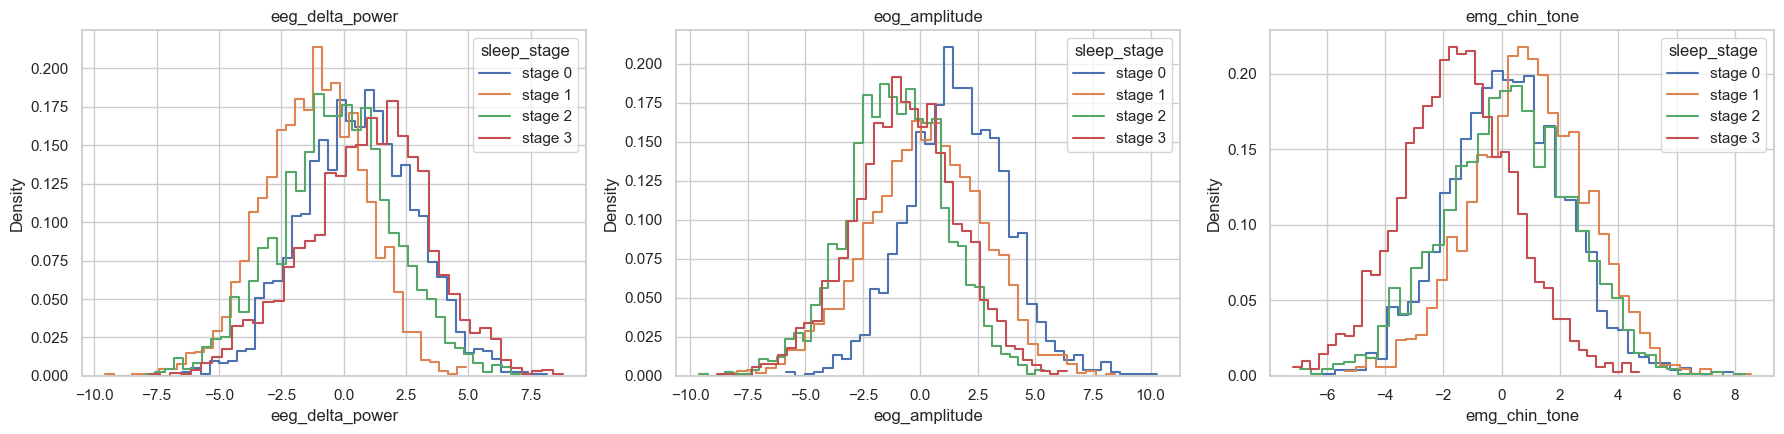

In [5]:
key_features = ["eeg_delta_power", "eog_amplitude", "emg_chin_tone"]
stages = sorted(train[TARGET].unique())

fig, axes = plt.subplots(1, len(key_features), figsize=(6 * len(key_features), 4.5))
for ax, feat in zip(axes, key_features):
    for s in stages:
        sns.histplot(
            train.loc[train[TARGET] == s, feat],
            ax=ax, label=f"stage {s}", stat="density",
            bins=40, element="step", fill=False,
        )
    ax.set_title(feat)
    ax.legend(title="sleep_stage")
plt.tight_layout()
plt.show()

## Correlation heatmap

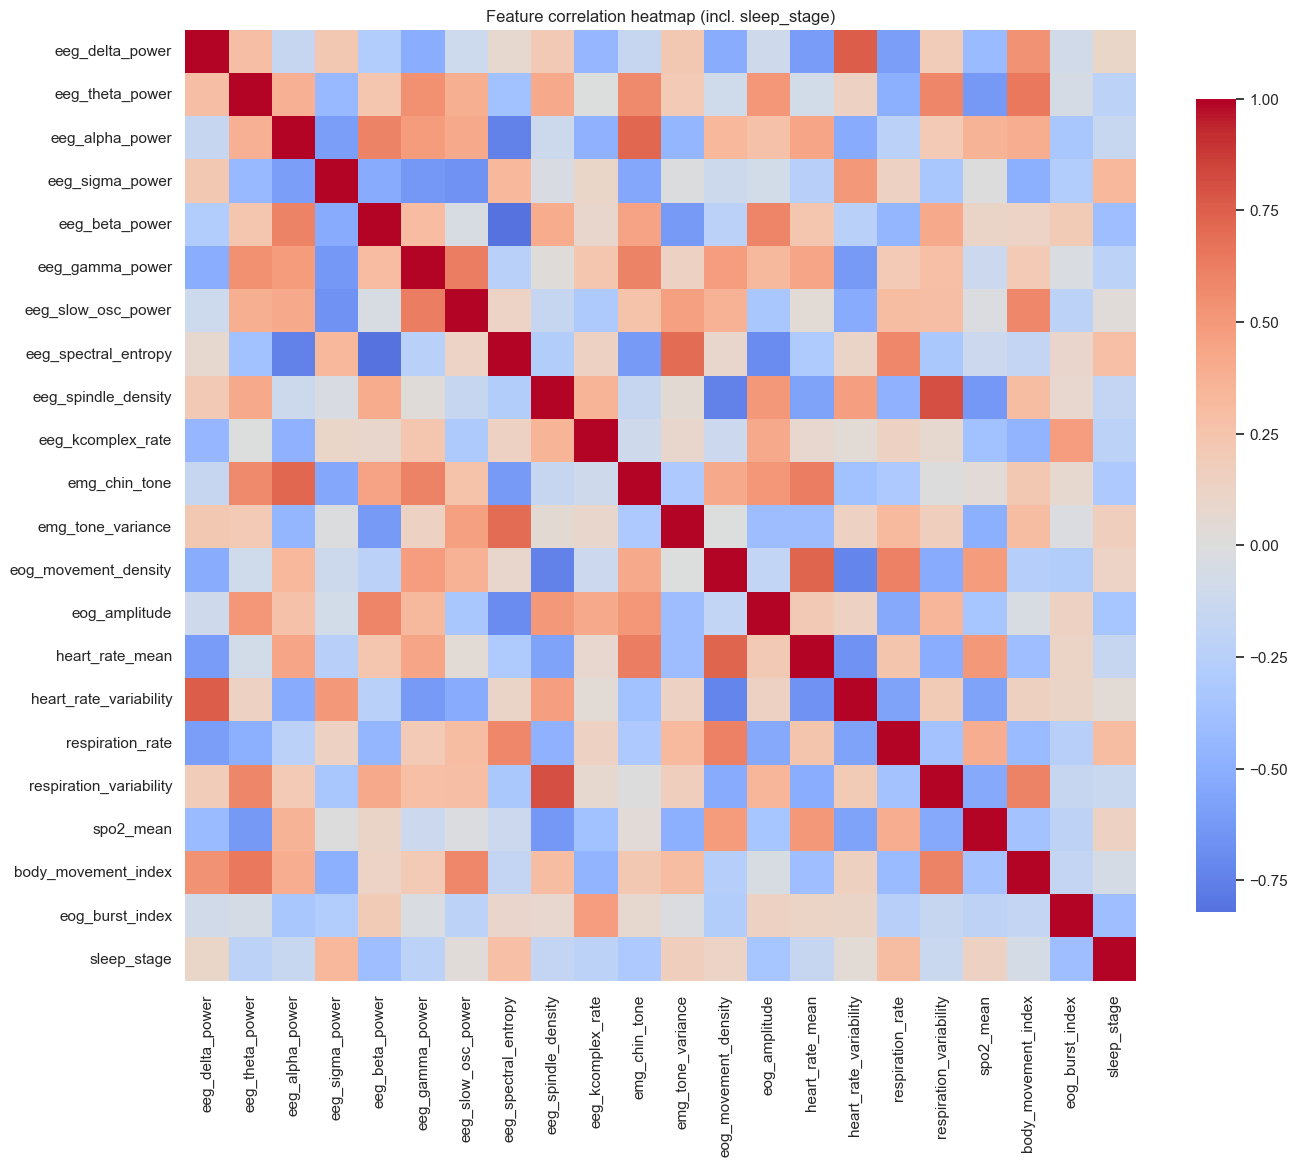

In [6]:
corr = train[features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation heatmap (incl. sleep_stage)")
plt.tight_layout()
plt.show()

## Which features separate the stages best?

A simple separation score: the variance of the per-class means divided by the overall variance (an eta-squared-like ratio). Higher = the class means are spread further apart relative to the feature's spread.

eog_burst_index            0.655
heart_rate_variability     0.410
eog_movement_density       0.394
eeg_alpha_power            0.313
respiration_rate           0.295
eeg_spindle_density        0.266
eeg_sigma_power            0.265
eeg_slow_osc_power         0.253
eeg_gamma_power            0.246
eeg_beta_power             0.239
eog_amplitude              0.222
heart_rate_mean            0.221
emg_chin_tone              0.220
spo2_mean                  0.207
eeg_spectral_entropy       0.190
eeg_kcomplex_rate          0.171
eeg_delta_power            0.151
respiration_variability    0.138
eeg_theta_power            0.071
emg_tone_variance          0.065
body_movement_index        0.017
dtype: float64


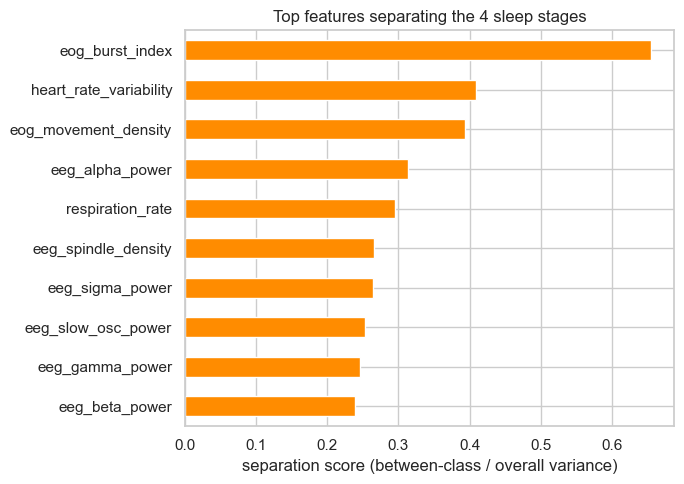

In [7]:
sep = {}
for f in features:
    class_means = train.groupby(TARGET)[f].mean()
    sep[f] = class_means.var() / train[f].var()

sep = pd.Series(sep).sort_values(ascending=False)
print(sep.round(3))

ax = sep.head(10).iloc[::-1].plot(kind="barh", color="darkorange", figsize=(7, 5))
ax.set_xlabel("separation score (between-class / overall variance)")
ax.set_title("Top features separating the 4 sleep stages")
plt.tight_layout()
plt.show()

## Summary

- **Shapes:** `train` has 9,000 rows × 23 columns (21 features + `id` + `sleep_stage`); `test` has 5,000 rows × 22 columns (no target); `sample_submission` has 5,000 rows mirroring `test` ids with a placeholder `sleep_stage`.
- **Class balance:** the four stages are fairly even — stage 1 (≈ 27%) and stage 3 (≈ 26%) are the largest, stage 0 (≈ 22%) the smallest. No severe imbalance, so plain accuracy is a reasonable baseline metric.
- **Missing values:** one column has substantial missingness — **`eog_burst_index` is ~50% missing** (50.0% train, 49.5% test); every other feature is fully populated. This column needs an explicit missing-value strategy (flag + imputation).
- **Most discriminative features** (by the separation score above): **`eog_burst_index`** stands out clearly (score ≈ 0.65, computed on non-missing rows), followed by **`heart_rate_variability`**, **`eog_movement_density`**, **`eeg_alpha_power`**, and **`respiration_rate`**. EEG spindle/sigma activity (`eeg_spindle_density`, `eeg_sigma_power`) and `eeg_slow_osc_power` form a second tier.
- **Interpretation:** eye-movement signals (EOG burst/movement) are the single strongest separators — consistent with REM vs. non-REM physiology — while autonomic signals (HRV, respiration) and EEG spectral bands (alpha, sigma/spindles, slow oscillations) provide complementary structure. The chosen histogram features `eeg_delta_power` and `emg_chin_tone` separate the classes only weakly on their own, so models will need to combine features rather than rely on any single channel.
- **Modelling note:** features appear pre-standardised (roughly zero-mean, unit-ish scale, some negatives), and inter-feature correlations are mostly modest — a gradient-boosted tree or a small MLP on the raw features is a sensible starting point. Because `eog_burst_index` is both the strongest separator and half-missing, the fact that a value *is missing* may itself be informative — hence the binary missing-flag below.

# Preprocessing

A single `preprocess` function that:

1. Selects features = all columns except `id` and `sleep_stage`.
2. Adds a binary `eog_burst_missing` flag (1 where `eog_burst_index` is NaN).
3. Fills missing `eog_burst_index` with the **median computed on train only**.
4. Returns two feature sets — a **StandardScaler-scaled** version (for linear models / SVM) and a **raw** version (for tree models).

All statistics (median, scaler mean/std) are fit on **train only** and then applied to both train and test, so no test information leaks into the transforms.

In [8]:
from sklearn.preprocessing import StandardScaler

ID_COL = "id"
TARGET = "sleep_stage"


def preprocess(train_df, test_df):
    """Build raw and scaled feature matrices, fitting all stats on train only.

    Returns a dict with:
      X_train_raw, X_test_raw       -> for tree models (unscaled)
      X_train_scaled, X_test_scaled -> for linear models / SVM (StandardScaler)
      y_train                       -> target for train
      feature_names                 -> ordered list of feature columns
      scaler, eog_median            -> fitted artefacts (for reuse / inspection)
    """
    # 1. Feature selection: everything except id and target.
    feature_cols = [c for c in train_df.columns if c not in (ID_COL, TARGET)]

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    # 2. Binary missing-flag for eog_burst_index (before imputation).
    X_train["eog_burst_missing"] = X_train["eog_burst_index"].isna().astype(int)
    X_test["eog_burst_missing"] = X_test["eog_burst_index"].isna().astype(int)

    # 3. Impute eog_burst_index with the TRAIN median only (no test leakage).
    eog_median = X_train["eog_burst_index"].median()
    X_train["eog_burst_index"] = X_train["eog_burst_index"].fillna(eog_median)
    X_test["eog_burst_index"] = X_test["eog_burst_index"].fillna(eog_median)

    feature_names = list(X_train.columns)  # includes the new flag

    # 4a. Raw version for tree models.
    X_train_raw = X_train.copy()
    X_test_raw = X_test.copy()

    # 4b. Scaled version for linear models / SVM. Scaler is fit on TRAIN only.
    scaler = StandardScaler().fit(X_train.values)
    X_train_scaled = pd.DataFrame(
        scaler.transform(X_train.values), columns=feature_names, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test.values), columns=feature_names, index=X_test.index
    )

    y_train = train_df[TARGET].copy() if TARGET in train_df.columns else None

    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "feature_names": feature_names,
        "scaler": scaler,
        "eog_median": eog_median,
    }


prep = preprocess(train, test)

print("eog_burst_index train median used for imputation:", round(prep["eog_median"], 5))
print("feature count (incl. eog_burst_missing flag):", len(prep["feature_names"]))
print("\nshapes:")
for k in ["X_train_raw", "X_test_raw", "X_train_scaled", "X_test_scaled"]:
    print(f"  {k:16s} {prep[k].shape}")

# Sanity checks: no remaining NaNs, scaled train ~ mean 0 / std 1, test reuses train stats.
print("\nremaining NaNs -> train_raw:", int(prep["X_train_raw"].isna().sum().sum()),
      "| test_raw:", int(prep["X_test_raw"].isna().sum().sum()))
print("scaled train mean (mean abs):", round(prep["X_train_scaled"].mean().abs().mean(), 6),
      "| scaled train std (mean):", round(prep["X_train_scaled"].std(ddof=0).mean(), 4))
print("eog_burst_missing share -> train:", round(prep["X_train_raw"]["eog_burst_missing"].mean(), 4),
      "| test:", round(prep["X_test_raw"]["eog_burst_missing"].mean(), 4))

eog_burst_index train median used for imputation: -0.0022
feature count (incl. eog_burst_missing flag): 22

shapes:
  X_train_raw      (9000, 22)
  X_test_raw       (5000, 22)
  X_train_scaled   (9000, 22)
  X_test_scaled    (5000, 22)

remaining NaNs -> train_raw: 0 | test_raw: 0
scaled train mean (mean abs): 0.0 | scaled train std (mean): 1.0
eog_burst_missing share -> train: 0.5001 | test: 0.4954


# Cross-validation harness

A shared `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` and an `evaluate(model, X, y)` helper. It uses `cross_val_predict` to get out-of-fold predictions, then prints the **macro-F1** (`f1_score(..., average='macro')`) and a short `classification_report`. We reuse this to compare every model in the next step — pass `prep['X_train_scaled']` for linear models / SVM and `prep['X_train_raw']` for tree models, with `y = prep['y_train']`.

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report

# Shared CV splitter — same folds for every model so comparisons are fair.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(model, X, y, name=None):
    """Out-of-fold evaluation of a classifier.

    Runs 5-fold stratified cross_val_predict, prints macro-F1 and a
    classification report, and returns the macro-F1 score.

    Pass the SCALED feature set for linear models / SVM and the RAW set
    for tree models; y is prep['y_train'].
    """
    label = name or type(model).__name__
    oof_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

    macro_f1 = f1_score(y, oof_pred, average="macro")
    print(f"=== {label} ===")
    print(f"macro-F1 (out-of-fold): {macro_f1:.4f}\n")
    print(classification_report(y, oof_pred, digits=3))
    return macro_f1


# Quick smoke test of the harness (also a baseline reference number).
from sklearn.linear_model import LogisticRegression

_ = evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    prep["X_train_scaled"], prep["y_train"],
    name="LogisticRegression (scaled) — harness smoke test",
)

=== LogisticRegression (scaled) — harness smoke test ===
macro-F1 (out-of-fold): 0.7440

              precision    recall  f1-score   support

           0      0.795     0.806     0.800      2001
           1      0.757     0.761     0.759      2442
           2      0.689     0.679     0.684      2237
           3      0.734     0.731     0.733      2320

    accuracy                          0.743      9000
   macro avg      0.744     0.744     0.744      9000
weighted avg      0.743     0.743     0.743      9000



# Model comparison

Compare three models on the same 5-fold stratified CV via the `evaluate()` harness:

- **LogisticRegression** and **SVC (RBF)** on the **scaled** features.
- **RandomForestClassifier** on the **raw** features.

We collect each model's out-of-fold macro-F1 into a dict and print a summary table sorted best → worst, comparing against the 0.744 LogisticRegression baseline.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

y = prep["y_train"]
X_scaled = prep["X_train_scaled"]
X_raw = prep["X_train_raw"]

scores = {}

# Scaled features: linear model + SVM.
scores["LogisticRegression (scaled)"] = evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_scaled, y, name="LogisticRegression (scaled)")
print()

scores["SVC rbf (scaled)"] = evaluate(
    SVC(kernel="rbf", random_state=42),
    X_scaled, y, name="SVC rbf (scaled)")
print()

# Raw features: tree ensemble.
scores["RandomForest (raw)"] = evaluate(
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    X_raw, y, name="RandomForest (raw)")
print()

# Sorted summary table, best -> worst, vs the 0.744 LogisticRegression baseline.
BASELINE = 0.744
ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)

print("=" * 56)
print(f"{'model':<32}{'macro-F1':>10}{'vs base':>10}")
print("-" * 56)
for name, s in ranked:
    print(f"{name:<32}{s:>10.4f}{s - BASELINE:>+10.4f}")
print("=" * 56)

best_name, best_score = ranked[0]
print(f"\nWinner: {best_name} (macro-F1 = {best_score:.4f}), "
      f"beating the {BASELINE} LogisticRegression baseline by {best_score - BASELINE:+.4f} "
      f"({(best_score - BASELINE) / BASELINE * 100:+.1f}%).")

=== LogisticRegression (scaled) ===
macro-F1 (out-of-fold): 0.7440

              precision    recall  f1-score   support

           0      0.795     0.806     0.800      2001
           1      0.757     0.761     0.759      2442
           2      0.689     0.679     0.684      2237
           3      0.734     0.731     0.733      2320

    accuracy                          0.743      9000
   macro avg      0.744     0.744     0.744      9000
weighted avg      0.743     0.743     0.743      9000




=== SVC rbf (scaled) ===
macro-F1 (out-of-fold): 0.8297

              precision    recall  f1-score   support

           0      0.862     0.851     0.857      2001
           1      0.844     0.852     0.848      2442
           2      0.786     0.776     0.781      2237
           3      0.828     0.840     0.834      2320

    accuracy                          0.830      9000
   macro avg      0.830     0.830     0.830      9000
weighted avg      0.829     0.830     0.829      9000




=== RandomForest (raw) ===
macro-F1 (out-of-fold): 0.7955

              precision    recall  f1-score   support

           0      0.825     0.813     0.819      2001
           1      0.807     0.847     0.826      2442
           2      0.764     0.700     0.731      2237
           3      0.790     0.822     0.806      2320

    accuracy                          0.797      9000
   macro avg      0.796     0.796     0.795      9000
weighted avg      0.796     0.797     0.796      9000


model                             macro-F1   vs base
--------------------------------------------------------
SVC rbf (scaled)                    0.8297   +0.0857
RandomForest (raw)                  0.7955   +0.0515
LogisticRegression (scaled)         0.7440   +0.0000

Winner: SVC rbf (scaled) (macro-F1 = 0.8297), beating the 0.744 LogisticRegression baseline by +0.0857 (+11.5%).


# Final model & submission

Refit the winning **SVC (RBF)** on the full scaled training set, predict `sleep_stage` for the scaled test set, and write `submission.csv` (columns `id`, `sleep_stage`) in the day9 folder. Then verify the shape, header, first rows, and class distribution, and confirm the format matches `sample_submission.csv`.

In [11]:
from sklearn.svm import SVC

# Train the winning model on the FULL scaled training set.
final_model = SVC(kernel="rbf", random_state=42)
final_model.fit(prep["X_train_scaled"], prep["y_train"])

# Predict on the scaled test set.
test_pred = final_model.predict(prep["X_test_scaled"]).astype(int)

# Build submission: id from test_df, integer sleep_stage predictions.
submission = pd.DataFrame({
    "id": test["id"].values,
    "sleep_stage": test_pred,
})

SUBMISSION_PATH = "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"saved -> {SUBMISSION_PATH}")

# --- Verification ---
print("\nshape:", submission.shape)
assert submission.shape[0] == 5000, "expected 5000 rows"

print("\nheader:", list(submission.columns))
print("\nfirst 5 rows:")
print(submission.head().to_string(index=False))

print("\npredicted class distribution:")
print(submission["sleep_stage"].value_counts().sort_index())
print("\nproportions:")
print(submission["sleep_stage"].value_counts(normalize=True).sort_index().round(4))

# --- Confirm format matches sample_submission.csv exactly ---
sample = pd.read_csv("inception/sample_submission.csv")
checks = {
    "same columns / order": list(submission.columns) == list(sample.columns),
    "same row count": len(submission) == len(sample),
    "same ids (order-matched)": submission["id"].tolist() == sample["id"].tolist(),
    "sleep_stage is integer": pd.api.types.is_integer_dtype(submission["sleep_stage"]),
    # NOTE: sample_submission.csv is an all-ones placeholder, so we validate predicted
    # labels against the TRAIN classes, not the sample's (dummy) label set.
    "labels are valid train classes": set(submission["sleep_stage"]).issubset(set(prep["y_train"].unique())),
}
print("\nformat checks vs sample_submission.csv:")
for k, v in checks.items():
    print(f"  [{'OK' if v else 'FAIL'}] {k}")
assert all(checks.values()), "submission format does not match sample_submission.csv"
print("\nAll format checks passed — submission matches sample_submission.csv.")

saved -> submission.csv

shape: (5000, 2)

header: ['id', 'sleep_stage']

first 5 rows:
  id  sleep_stage
9000            0
9001            3
9002            1
9003            3
9004            3

predicted class distribution:
sleep_stage
0    1122
1    1286
2    1301
3    1291
Name: count, dtype: int64

proportions:
sleep_stage
0    0.2244
1    0.2572
2    0.2602
3    0.2582
Name: proportion, dtype: float64

format checks vs sample_submission.csv:
  [OK] same columns / order
  [OK] same row count
  [OK] same ids (order-matched)
  [OK] sleep_stage is integer
  [OK] labels are valid train classes

All format checks passed — submission matches sample_submission.csv.


# Improving on the SVC submission

Current best: SVC(kernel='rbf') — CV macro-F1 = 0.83, public 0.835. Every variant below is validated with the existing 5-fold `evaluate()` harness; we only adopt a change if its CV macro-F1 beats the current best.

## Step 1 — Tune the RBF SVM

`GridSearchCV` over `C in [1, 3, 10, 30]` and `gamma in ['scale', 0.01, 0.03, 0.1]`, `scoring='f1_macro'`, using the same `StratifiedKFold(5)`.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.base import clone

y = prep["y_train"]
X_scaled = prep["X_train_scaled"]

# results holds, per variant: CV macro-F1 + the estimator factory and feature sets to refit on.
results = {}

# Reference: current (untuned) SVC via the evaluate() harness.
current_svc = SVC(kernel="rbf", random_state=42)
results["current SVC (scaled)"] = {
    "score": evaluate(current_svc, X_scaled, y, name="current SVC (scaled)"),
    "make": lambda: SVC(kernel="rbf", random_state=42),
    "Xtr": X_scaled, "Xte": prep["X_test_scaled"],
}
print()

param_grid = {"C": [1, 3, 10, 30], "gamma": ["scale", 0.01, 0.03, 0.1]}
grid = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1,
)
grid.fit(X_scaled, y)

best_svc_params = grid.best_params_
print("\nbest params:", best_svc_params)
print(f"best GridSearchCV f1_macro: {grid.best_score_:.4f}")

# Re-score the tuned model through the SAME evaluate() harness for a like-for-like comparison.
def make_tuned_svc():
    return SVC(kernel="rbf", random_state=42, **best_svc_params)

print()
results["tuned SVC (scaled)"] = {
    "score": evaluate(make_tuned_svc(), X_scaled, y, name="tuned SVC (scaled)"),
    "make": make_tuned_svc,
    "Xtr": X_scaled, "Xte": prep["X_test_scaled"],
}

=== current SVC (scaled) ===
macro-F1 (out-of-fold): 0.8297

              precision    recall  f1-score   support

           0      0.862     0.851     0.857      2001
           1      0.844     0.852     0.848      2442
           2      0.786     0.776     0.781      2237
           3      0.828     0.840     0.834      2320

    accuracy                          0.830      9000
   macro avg      0.830     0.830     0.830      9000
weighted avg      0.829     0.830     0.829      9000


Fitting 5 folds for each of 16 candidates, totalling 80 fits



best params: {'C': 30, 'gamma': 0.01}
best GridSearchCV f1_macro: 0.8346



=== tuned SVC (scaled) ===
macro-F1 (out-of-fold): 0.8346

              precision    recall  f1-score   support

           0      0.868     0.854     0.861      2001
           1      0.852     0.848     0.850      2442
           2      0.786     0.795     0.790      2237
           3      0.834     0.840     0.837      2320

    accuracy                          0.834      9000
   macro avg      0.835     0.834     0.835      9000
weighted avg      0.834     0.834     0.834      9000



## Step 2 — EEG band-ratio features

Add theta/delta, beta/delta, alpha/delta, sigma/delta (small epsilon on the denominator to avoid division by zero) to both train and test, re-fit the `StandardScaler` on the augmented **train** only, re-scale test, and re-evaluate the tuned SVC. Keep the features only if CV improves.

In [13]:
EPS = 1e-6

def add_band_ratios(X):
    """Append EEG band-power ratios (relative to delta) to a raw feature frame."""
    X = X.copy()
    denom = X["eeg_delta_power"] + EPS
    X["theta_delta_ratio"] = X["eeg_theta_power"] / denom
    X["beta_delta_ratio"]  = X["eeg_beta_power"]  / denom
    X["alpha_delta_ratio"] = X["eeg_alpha_power"] / denom
    X["sigma_delta_ratio"] = X["eeg_sigma_power"] / denom
    return X

X_train_aug = add_band_ratios(prep["X_train_raw"])
X_test_aug  = add_band_ratios(prep["X_test_raw"])

# Re-fit scaler on augmented TRAIN only, then apply to test (no leakage).
scaler_aug = StandardScaler().fit(X_train_aug.values)
X_train_aug_scaled = pd.DataFrame(
    scaler_aug.transform(X_train_aug.values), columns=X_train_aug.columns, index=X_train_aug.index)
X_test_aug_scaled = pd.DataFrame(
    scaler_aug.transform(X_test_aug.values), columns=X_test_aug.columns, index=X_test_aug.index)

print("augmented feature count:", X_train_aug_scaled.shape[1], "(was", X_scaled.shape[1], ")\n")

results["tuned SVC + band ratios"] = {
    "score": evaluate(make_tuned_svc(), X_train_aug_scaled, y, name="tuned SVC + band ratios (scaled)"),
    "make": make_tuned_svc,
    "Xtr": X_train_aug_scaled, "Xte": X_test_aug_scaled,
}

keep = results["tuned SVC + band ratios"]["score"] > results["tuned SVC (scaled)"]["score"]
print("\nband ratios improve CV?", keep,
      f"({results['tuned SVC + band ratios']['score']:.4f} vs {results['tuned SVC (scaled)']['score']:.4f})")

augmented feature count: 26 (was 22 )



=== tuned SVC + band ratios (scaled) ===
macro-F1 (out-of-fold): 0.8340

              precision    recall  f1-score   support

           0      0.856     0.859     0.857      2001
           1      0.853     0.847     0.850      2442
           2      0.788     0.794     0.791      2237
           3      0.839     0.837     0.838      2320

    accuracy                          0.834      9000
   macro avg      0.834     0.834     0.834      9000
weighted avg      0.834     0.834     0.834      9000


band ratios improve CV? False (0.8340 vs 0.8346)


## Step 3 — Soft-voting ensemble

Soft-voting `VotingClassifier` over the tuned SVC (`probability=True`) and `RandomForestClassifier(n_estimators=400, random_state=42)`, on the scaled features, evaluated with the harness.

In [14]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

def make_ensemble():
    svc = SVC(kernel="rbf", random_state=42, probability=True, **best_svc_params)
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    return VotingClassifier(estimators=[("svc", svc), ("rf", rf)], voting="soft", n_jobs=-1)

results["soft-voting ensemble"] = {
    "score": evaluate(make_ensemble(), X_scaled, y, name="soft-voting SVC+RF (scaled)"),
    "make": make_ensemble,
    "Xtr": X_scaled, "Xte": prep["X_test_scaled"],
}

=== soft-voting SVC+RF (scaled) ===
macro-F1 (out-of-fold): 0.8326

              precision    recall  f1-score   support

           0      0.864     0.857     0.860      2001
           1      0.844     0.858     0.851      2442
           2      0.792     0.772     0.782      2237
           3      0.831     0.843     0.837      2320

    accuracy                          0.833      9000
   macro avg      0.833     0.833     0.833      9000
weighted avg      0.832     0.833     0.832      9000



## Comparison & final submission

Compare all variants. If the best CV macro-F1 beats 0.83, retrain that variant on the full train set, predict test, and overwrite `submission.csv`.

In [15]:
ORDER = ["current SVC (scaled)", "tuned SVC (scaled)", "tuned SVC + band ratios", "soft-voting ensemble"]
CURRENT_BEST = 0.83

print("=" * 58)
print(f"{'variant':<32}{'CV macro-F1':>14}{'vs 0.83':>12}")
print("-" * 58)
for name in ORDER:
    s = results[name]["score"]
    print(f"{name:<32}{s:>14.4f}{s - CURRENT_BEST:>+12.4f}")
print("=" * 58)

best_name = max(results, key=lambda k: results[k]["score"])
best = results[best_name]
print(f"\nbest variant: {best_name}  (CV macro-F1 = {best['score']:.4f})")

if best["score"] > CURRENT_BEST:
    print(f"-> beats 0.83 by {best['score'] - CURRENT_BEST:+.4f}; retraining on full train and writing submission.csv")
    final_model = best["make"]()
    final_model.fit(best["Xtr"], y)
    test_pred = final_model.predict(best["Xte"]).astype(int)

    submission = pd.DataFrame({"id": test["id"].values, "sleep_stage": test_pred})
    submission.to_csv("submission.csv", index=False)

    assert submission.shape == (5000, 2)
    assert list(submission.columns) == ["id", "sleep_stage"]
    assert submission["id"].tolist() == pd.read_csv("inception/sample_submission.csv")["id"].tolist()

    print(f"\nsaved submission.csv  shape={submission.shape}")
    print("new CV macro-F1:", round(best["score"], 4))
    print("\npredicted class distribution:")
    print(submission["sleep_stage"].value_counts().sort_index())
    print("\nproportions:")
    print(submission["sleep_stage"].value_counts(normalize=True).sort_index().round(4))
else:
    print(f"-> does NOT beat 0.83; keeping the existing submission.csv unchanged.")

variant                            CV macro-F1     vs 0.83
----------------------------------------------------------
current SVC (scaled)                    0.8297     -0.0003
tuned SVC (scaled)                      0.8346     +0.0046
tuned SVC + band ratios                 0.8340     +0.0040
soft-voting ensemble                    0.8326     +0.0026

best variant: tuned SVC (scaled)  (CV macro-F1 = 0.8346)
-> beats 0.83 by +0.0046; retraining on full train and writing submission.csv



saved submission.csv  shape=(5000, 2)
new CV macro-F1: 0.8346

predicted class distribution:
sleep_stage
0    1131
1    1273
2    1307
3    1289
Name: count, dtype: int64

proportions:
sleep_stage
0    0.2262
1    0.2546
2    0.2614
3    0.2578
Name: proportion, dtype: float64


# Round 2 — push past tuned SVC (CV 0.8346)

All variants validated with the same 5-fold `evaluate()` harness; `submission.csv` is overwritten only if a variant beats **0.8346**.

## (1) Finer SVM grid

`GridSearchCV` around the current region: `C in [2,3,5,7,10]`, `gamma in ['scale',0.02,0.03,0.05,0.07]`, `scoring='f1_macro'`, same `StratifiedKFold(5)`. (The prior best C=30, gamma=0.01 sits outside this grid, so it stays in the comparison as the reference to beat.)

In [16]:
# Round-2 comparison dict; seed it with the current champion (tuned SVC, already in `results`).
results2 = {
    "tuned SVC C30 g0.01 (baseline)": {
        "score": results["tuned SVC (scaled)"]["score"],
        "make": make_tuned_svc,
        "Xtr": prep["X_train_scaled"], "Xte": prep["X_test_scaled"],
    }
}

param_grid2 = {"C": [2, 3, 5, 7, 10], "gamma": ["scale", 0.02, 0.03, 0.05, 0.07]}
grid2 = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid2, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1,
)
grid2.fit(prep["X_train_scaled"], y)
print("\nfiner-grid best params:", grid2.best_params_)
print(f"finer-grid best f1_macro: {grid2.best_score_:.4f}\n")

refined_params = grid2.best_params_
def make_refined_svc():
    return SVC(kernel="rbf", random_state=42, **refined_params)

results2["refined SVC (scaled)"] = {
    "score": evaluate(make_refined_svc(), prep["X_train_scaled"], y, name="refined SVC (scaled)"),
    "make": make_refined_svc,
    "Xtr": prep["X_train_scaled"], "Xte": prep["X_test_scaled"],
}

# Overall best SVC params (for the ensemble): pick whichever scores higher via the harness.
if results2["refined SVC (scaled)"]["score"] > results2["tuned SVC C30 g0.01 (baseline)"]["score"]:
    best_overall_svc_params = refined_params
else:
    best_overall_svc_params = best_svc_params  # {'C': 30, 'gamma': 0.01}
print("\nbest SVC params for ensemble:", best_overall_svc_params)

Fitting 5 folds for each of 25 candidates, totalling 125 fits



finer-grid best params: {'C': 7, 'gamma': 0.02}
finer-grid best f1_macro: 0.8355



=== refined SVC (scaled) ===
macro-F1 (out-of-fold): 0.8355

              precision    recall  f1-score   support

           0      0.867     0.857     0.862      2001
           1      0.851     0.853     0.852      2442
           2      0.792     0.789     0.791      2237
           3      0.833     0.843     0.838      2320

    accuracy                          0.835      9000
   macro avg      0.836     0.835     0.836      9000
weighted avg      0.835     0.835     0.835      9000


best SVC params for ensemble: {'C': 7, 'gamma': 0.02}


## (2) CatBoost on raw features (NaNs unfilled)

`CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05, loss_function='MultiClass', random_seed=42)` on the raw features with `eog_burst_index` NaNs left in place (CatBoost handles missing natively). The binary `eog_burst_missing` flag is kept. CatBoost's `MultiClass` predict returns a 2-D column, so a thin subclass ravels it for the harness.

In [17]:
from catboost import CatBoostClassifier

# Raw feature matrices with NaNs UNFILLED (plus the eog_burst_missing flag), built directly from
# the source CSVs so no imputation leaks in.
feature_cols = [c for c in train.columns if c not in ("id", "sleep_stage")]

def make_raw_nan(df):
    X = df[feature_cols].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X

X_train_raw_nan = make_raw_nan(train)
X_test_raw_nan = make_raw_nan(test)
print("raw-NaN train shape:", X_train_raw_nan.shape,
      "| eog NaNs kept:", int(X_train_raw_nan["eog_burst_index"].isna().sum()))

class CatBoostRaveled(CatBoostClassifier):
    """CatBoost whose predict() returns 1-D labels (MultiClass returns an (n,1) column)."""
    def predict(self, data, **kw):
        return super().predict(data, **kw).ravel()

def make_catboost():
    return CatBoostRaveled(
        iterations=800, depth=6, learning_rate=0.05,
        loss_function="MultiClass", random_seed=42, verbose=False,
    )

results2["CatBoost (raw, NaN-native)"] = {
    "score": evaluate(make_catboost(), X_train_raw_nan, y, name="CatBoost (raw, NaN-native)"),
    "make": make_catboost,
    "Xtr": X_train_raw_nan, "Xte": X_test_raw_nan,
}

raw-NaN train shape: (9000, 22) | eog NaNs kept: 4501


=== CatBoost (raw, NaN-native) ===
macro-F1 (out-of-fold): 0.8235

              precision    recall  f1-score   support

           0      0.854     0.848     0.851      2001
           1      0.837     0.854     0.845      2442
           2      0.782     0.760     0.771      2237
           3      0.821     0.832     0.827      2320

    accuracy                          0.824      9000
   macro avg      0.824     0.823     0.824      9000
weighted avg      0.823     0.824     0.823      9000



## (3) Soft-voting ensemble — SVC + CatBoost

Both estimators receive the **same** raw-with-NaN matrix; each does its own preprocessing inside a `Pipeline`: the SVC pipeline imputes (median, fit per-fold) → scales → `SVC(probability=True)`, while CatBoost takes the raw NaNs directly. Soft voting on the predicted probabilities.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import VotingClassifier

def make_svc_pipeline():
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", random_state=42, probability=True, **best_overall_svc_params)),
    ])

def make_svc_cat_ensemble():
    return VotingClassifier(
        estimators=[("svc", make_svc_pipeline()), ("cat", make_catboost())],
        voting="soft", n_jobs=-1,
    )

# Both branches get the same raw-with-NaN matrix; pipelines handle their own preprocessing per fold.
results2["SVC + CatBoost ensemble"] = {
    "score": evaluate(make_svc_cat_ensemble(), X_train_raw_nan, y, name="SVC + CatBoost soft-vote"),
    "make": make_svc_cat_ensemble,
    "Xtr": X_train_raw_nan, "Xte": X_test_raw_nan,
}

=== SVC + CatBoost soft-vote ===
macro-F1 (out-of-fold): 0.8342

              precision    recall  f1-score   support

           0      0.866     0.856     0.861      2001
           1      0.846     0.858     0.852      2442
           2      0.792     0.780     0.786      2237
           3      0.834     0.842     0.838      2320

    accuracy                          0.834      9000
   macro avg      0.834     0.834     0.834      9000
weighted avg      0.834     0.834     0.834      9000



## Comparison & submission

Compare all round-2 variants against the **0.8346** baseline. Overwrite `submission.csv` only if the best beats it.

In [19]:
BASELINE = 0.8346
ORDER2 = ["tuned SVC C30 g0.01 (baseline)", "refined SVC (scaled)",
          "CatBoost (raw, NaN-native)", "SVC + CatBoost ensemble"]

print("=" * 60)
print(f"{'variant':<34}{'CV macro-F1':>14}{'vs 0.8346':>12}")
print("-" * 60)
for name in ORDER2:
    s = results2[name]["score"]
    print(f"{name:<34}{s:>14.4f}{s - BASELINE:>+12.4f}")
print("=" * 60)

best_name = max(results2, key=lambda k: results2[k]["score"])
best = results2[best_name]
print(f"\nbest variant: {best_name}  (CV macro-F1 = {best['score']:.4f})")

if best["score"] > BASELINE:
    print(f"-> beats 0.8346 by {best['score'] - BASELINE:+.4f}; retraining on full train and overwriting submission.csv")
    final_model = best["make"]()
    final_model.fit(best["Xtr"], y)
    test_pred = np.asarray(final_model.predict(best["Xte"])).ravel().astype(int)

    submission = pd.DataFrame({"id": test["id"].values, "sleep_stage": test_pred})
    submission.to_csv("submission.csv", index=False)
    assert submission.shape == (5000, 2)
    assert submission["id"].tolist() == pd.read_csv("inception/sample_submission.csv")["id"].tolist()

    print(f"\nsaved submission.csv  shape={submission.shape}")
    print("new CV macro-F1:", round(best["score"], 4))
    print("\npredicted class distribution:")
    print(submission["sleep_stage"].value_counts().sort_index())
    print(submission["sleep_stage"].value_counts(normalize=True).sort_index().round(4))
else:
    print(f"-> nothing beats 0.8346; keeping the existing tuned-SVC submission.csv unchanged.")

variant                              CV macro-F1   vs 0.8346
------------------------------------------------------------
tuned SVC C30 g0.01 (baseline)            0.8346     -0.0000
refined SVC (scaled)                      0.8355     +0.0009
CatBoost (raw, NaN-native)                0.8235     -0.0111
SVC + CatBoost ensemble                   0.8342     -0.0004

best variant: refined SVC (scaled)  (CV macro-F1 = 0.8355)
-> beats 0.8346 by +0.0009; retraining on full train and overwriting submission.csv



saved submission.csv  shape=(5000, 2)
new CV macro-F1: 0.8355

predicted class distribution:
sleep_stage
0    1120
1    1281
2    1306
3    1293
Name: count, dtype: int64
sleep_stage
0    0.2240
1    0.2562
2    0.2612
3    0.2586
Name: proportion, dtype: float64


# Round 3 — feature engineering for the tuned SVC

Baseline to beat: tuned SVC (C=7, γ=0.02), CV macro-F1 = 0.8355. New features are kept only if CV improves by **≥ 0.003**. We also track **class 2 (Deep) F1**, the model's weakest class.

**Engineered set:** (1) relative band powers — each EEG band / sum of all band powers; (2) `delta_dominance = eeg_delta_power − (eeg_beta_power + eeg_gamma_power)`; (3) `eog_movement_density × eog_amplitude`. Re-fit `StandardScaler` (train only) and re-evaluate.

Separately: `PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)` on the scaled features inside a Pipeline with the tuned SVC.

In [20]:
from sklearn.model_selection import cross_val_predict

# "Tuned SVC" = current best params (C=7, gamma=0.02 after round 2).
def make_svc():
    return SVC(kernel="rbf", random_state=42, **best_overall_svc_params)

# Labels are sorted [0,1,2,3], so f1_score(average=None)[2] is class 2 (Deep).
def class2_f1(model, X, y):
    pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    return f1_score(y, pred, average=None)[2]

EPS = 1e-6
BANDS = ["eeg_delta_power", "eeg_theta_power", "eeg_alpha_power",
         "eeg_sigma_power", "eeg_beta_power", "eeg_gamma_power"]

def add_engineered(X):
    X = X.copy()
    band_sum = X[BANDS].sum(axis=1) + EPS
    for b in BANDS:
        X["rel_" + b.replace("eeg_", "").replace("_power", "")] = X[b] / band_sum
    X["delta_dominance"] = X["eeg_delta_power"] - (X["eeg_beta_power"] + X["eeg_gamma_power"])
    X["eog_md_x_amp"] = X["eog_movement_density"] * X["eog_amplitude"]
    return X

X_train_eng = add_engineered(prep["X_train_raw"])
X_test_eng = add_engineered(prep["X_test_raw"])

# Re-fit scaler on the augmented TRAIN only, apply to test (no leakage).
scaler_eng = StandardScaler().fit(X_train_eng.values)
X_train_eng_scaled = pd.DataFrame(
    scaler_eng.transform(X_train_eng.values), columns=X_train_eng.columns, index=X_train_eng.index)
X_test_eng_scaled = pd.DataFrame(
    scaler_eng.transform(X_test_eng.values), columns=X_test_eng.columns, index=X_test_eng.index)
print("engineered feature count:", X_train_eng_scaled.shape[1], "(was", prep["X_train_scaled"].shape[1], ")")
print("new columns:", [c for c in X_train_eng.columns if c not in prep["X_train_raw"].columns], "\n")

# Baseline (no new features) and engineered, both via the evaluate() harness.
base_macro = evaluate(make_svc(), prep["X_train_scaled"], y, name="tuned SVC — baseline (no new features)")
base_c2 = class2_f1(make_svc(), prep["X_train_scaled"], y)
print()
eng_macro = evaluate(make_svc(), X_train_eng_scaled, y, name="tuned SVC + engineered features")
eng_c2 = class2_f1(make_svc(), X_train_eng_scaled, y)

delta = eng_macro - base_macro
print(f"\nengineered vs baseline macro-F1: {eng_macro:.4f} vs {base_macro:.4f}  (delta {delta:+.4f})")
print(f"class 2 (Deep) F1: {eng_c2:.4f} vs {base_c2:.4f}  (delta {eng_c2 - base_c2:+.4f})")
print(f"keep engineered features (delta >= 0.003)? {delta >= 0.003}")

engineered feature count: 30 (was 22 )
new columns: ['rel_delta', 'rel_theta', 'rel_alpha', 'rel_sigma', 'rel_beta', 'rel_gamma', 'delta_dominance', 'eog_md_x_amp'] 



=== tuned SVC — baseline (no new features) ===
macro-F1 (out-of-fold): 0.8355

              precision    recall  f1-score   support

           0      0.867     0.857     0.862      2001
           1      0.851     0.853     0.852      2442
           2      0.792     0.789     0.791      2237
           3      0.833     0.843     0.838      2320

    accuracy                          0.835      9000
   macro avg      0.836     0.835     0.836      9000
weighted avg      0.835     0.835     0.835      9000



=== tuned SVC + engineered features ===
macro-F1 (out-of-fold): 0.8317

              precision    recall  f1-score   support

           0      0.862     0.855     0.859      2001
           1      0.850     0.847     0.849      2442
           2      0.783     0.785     0.784      2237
           3      0.832     0.839     0.835      2320

    accuracy                          0.831      9000
   macro avg      0.832     0.832     0.832      9000
weighted avg      0.831     0.831     0.831      9000




engineered vs baseline macro-F1: 0.8317 vs 0.8355  (delta -0.0039)
class 2 (Deep) F1: 0.7844 vs 0.7905  (delta -0.0061)
keep engineered features (delta >= 0.003)? False


In [21]:
from sklearn.preprocessing import PolynomialFeatures

# PolynomialFeatures(interaction_only) on the already-scaled features, then the tuned SVC.
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("svc", make_svc()),
])
n_poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False) \
    .fit(prep["X_train_scaled"]).n_output_features_
print(f"interaction expansion: {prep['X_train_scaled'].shape[1]} -> {n_poly} features\n")

poly_macro = evaluate(poly_pipe, prep["X_train_scaled"], y, name="PolynomialFeatures(deg2, interaction) + tuned SVC")
poly_c2 = class2_f1(poly_pipe, prep["X_train_scaled"], y)
print(f"\npoly vs baseline macro-F1: {poly_macro:.4f} vs {base_macro:.4f}  (delta {poly_macro - base_macro:+.4f})")
print(f"class 2 (Deep) F1: {poly_c2:.4f} vs {base_c2:.4f}  (delta {poly_c2 - base_c2:+.4f})")

interaction expansion: 22 -> 253 features



=== PolynomialFeatures(deg2, interaction) + tuned SVC ===
macro-F1 (out-of-fold): 0.7329

              precision    recall  f1-score   support

           0      0.822     0.698     0.755      2001
           1      0.652     0.850     0.738      2442
           2      0.752     0.629     0.685      2237
           3      0.767     0.741     0.754      2320

    accuracy                          0.733      9000
   macro avg      0.748     0.730     0.733      9000
weighted avg      0.744     0.733     0.733      9000




poly vs baseline macro-F1: 0.7329 vs 0.8355  (delta -0.1027)
class 2 (Deep) F1: 0.6853 vs 0.7905  (delta -0.1052)


In [22]:
rows = [
    ("tuned SVC (baseline)", base_macro, base_c2),
    ("+ engineered features", eng_macro, eng_c2),
    ("+ PolynomialFeatures(interaction)", poly_macro, poly_c2),
]
print("=" * 64)
print(f"{'variant':<38}{'macro-F1':>11}{'class2 F1':>11}")
print("-" * 64)
for name, m, c2 in rows:
    print(f"{name:<38}{m:>11.4f}{c2:>11.4f}")
print("=" * 64)
print(f"\nKEEP threshold: macro-F1 improvement >= 0.003 over baseline ({base_macro:.4f}).")
print(f"  engineered: delta {eng_macro - base_macro:+.4f}  -> {'KEEP' if eng_macro - base_macro >= 0.003 else 'DROP'}")
print(f"  poly:       delta {poly_macro - base_macro:+.4f}  -> {'KEEP' if poly_macro - base_macro >= 0.003 else 'DROP'}")
print(f"\nClass 2 (Deep) F1 improved?  engineered: {'YES' if eng_c2 > base_c2 else 'NO'}"
      f" ({eng_c2 - base_c2:+.4f}) | poly: {'YES' if poly_c2 > base_c2 else 'NO'} ({poly_c2 - base_c2:+.4f})")
print("\nsubmission.csv left unchanged (this round evaluates features only).")

variant                                  macro-F1  class2 F1
----------------------------------------------------------------
tuned SVC (baseline)                       0.8355     0.7905
+ engineered features                      0.8317     0.7844
+ PolynomialFeatures(interaction)          0.7329     0.6853

KEEP threshold: macro-F1 improvement >= 0.003 over baseline (0.8355).
  engineered: delta -0.0039  -> DROP
  poly:       delta -0.1027  -> DROP

Class 2 (Deep) F1 improved?  engineered: NO (-0.0061) | poly: NO (-0.1052)

submission.csv left unchanged (this round evaluates features only).


# Round 4 — classic ensemble models (raw features)

Evaluate three course ensembles on the **raw** features (`prep['X_train_raw']` — median-imputed `eog_burst_index` plus the `eog_burst_missing` flag; tree models need no scaling), via the same 5-fold `evaluate()` harness. Compare against the tuned SVC (0.835).

In [23]:
from sklearn.ensemble import (GradientBoostingClassifier, AdaBoostClassifier,
                              BaggingClassifier)

X_raw = prep["X_train_raw"]

ensembles = {
    "GradientBoosting (300, lr0.05, d3)": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
    "AdaBoost (300)": AdaBoostClassifier(n_estimators=300, random_state=42),
    "Bagging (200)": BaggingClassifier(n_estimators=200, random_state=42),
}

round4 = {}
for name, model in ensembles.items():
    round4[name] = evaluate(model, X_raw, y, name=name)
    print()

SVC_REF = 0.835
ranked = sorted(round4.items(), key=lambda kv: kv[1], reverse=True)
print("=" * 58)
print(f"{'model':<36}{'macro-F1':>10}{'vs SVC':>10}")
print("-" * 58)
for name, s in ranked:
    print(f"{name:<36}{s:>10.4f}{s - SVC_REF:>+10.4f}")
print(f"{'tuned SVC (reference)':<36}{SVC_REF:>10.4f}{0.0:>+10.4f}")
print("=" * 58)

best_name, best_score = ranked[0]
print(f"\nbest ensemble: {best_name} (macro-F1 = {best_score:.4f}); "
      f"{'beats' if best_score > SVC_REF else 'does NOT beat'} the tuned SVC "
      f"({best_score - SVC_REF:+.4f}).")

=== GradientBoosting (300, lr0.05, d3) ===
macro-F1 (out-of-fold): 0.8096

              precision    recall  f1-score   support

           0      0.850     0.833     0.841      2001
           1      0.825     0.842     0.833      2442
           2      0.763     0.745     0.754      2237
           3      0.803     0.817     0.810      2320

    accuracy                          0.809      9000
   macro avg      0.810     0.809     0.810      9000
weighted avg      0.809     0.809     0.809      9000




=== AdaBoost (300) ===
macro-F1 (out-of-fold): 0.7367

              precision    recall  f1-score   support

           0      0.797     0.767     0.782      2001
           1      0.745     0.801     0.772      2442
           2      0.672     0.627     0.648      2237
           3      0.738     0.752     0.745      2320

    accuracy                          0.737      9000
   macro avg      0.738     0.737     0.737      9000
weighted avg      0.737     0.737     0.736      9000




=== Bagging (200) ===
macro-F1 (out-of-fold): 0.7859

              precision    recall  f1-score   support

           0      0.820     0.809     0.815      2001
           1      0.808     0.818     0.813      2442
           2      0.740     0.713     0.726      2237
           3      0.777     0.803     0.790      2320

    accuracy                          0.786      9000
   macro avg      0.786     0.786     0.786      9000
weighted avg      0.786     0.786     0.786      9000


model                                 macro-F1    vs SVC
----------------------------------------------------------
GradientBoosting (300, lr0.05, d3)      0.8096   -0.0254
Bagging (200)                           0.7859   -0.0491
AdaBoost (300)                          0.7367   -0.0983
tuned SVC (reference)                   0.8350   +0.0000

best ensemble: GradientBoosting (300, lr0.05, d3) (macro-F1 = 0.8096); does NOT beat the tuned SVC (-0.0254).


# Round 5 — three-model soft-voting ensemble

Soft-voting `VotingClassifier` over the tuned SVC (`probability=True`), RandomForest(400), and GradientBoosting(300, lr=0.05). Each estimator is wrapped in a `Pipeline` with its own preprocessing, so the voter receives one consistent raw-with-NaN matrix: the SVC pipeline imputes (median, per-fold) → scales → SVC, while the tree pipelines impute only (sklearn trees can't take NaN). Try `weights=[2,1,1]` and `[1,1,1]`.

Current best CV = 0.8355 → keep only if a weighting beats it by **≥ 0.003** (i.e. ≥ 0.8385); if so, retrain and overwrite `submission.csv`.

In [24]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def make_voter(weights):
    svc_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", random_state=42, probability=True, **best_overall_svc_params)),
    ])
    rf_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)),
    ])
    gb_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("gb", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)),
    ])
    return VotingClassifier(
        estimators=[("svc", svc_pipe), ("rf", rf_pipe), ("gb", gb_pipe)],
        voting="soft", weights=weights, n_jobs=-1,
    )

# Common input: raw features with NaNs unfilled (each pipeline imputes per-fold). Built in round 2.
WEIGHTINGS = [[2, 1, 1], [1, 1, 1]]
round5 = {}
for w in WEIGHTINGS:
    name = f"soft-vote SVC/RF/GB weights={w}"
    round5[tuple(w)] = {
        "score": evaluate(make_voter(w), X_train_raw_nan, y, name=name),
        "weights": w,
    }
    print()

CURRENT_BEST = 0.8355
best_w = max(round5, key=lambda k: round5[k]["score"])
best_score = round5[best_w]["score"]

print("=" * 52)
print(f"{'variant':<34}{'macro-F1':>10}{'vs best':>8}")
print("-" * 52)
for w in WEIGHTINGS:
    s = round5[tuple(w)]["score"]
    print(f"{'soft-vote weights=' + str(w):<34}{s:>10.4f}{s - CURRENT_BEST:>+8.4f}")
print(f"{'tuned SVC (current best)':<34}{CURRENT_BEST:>10.4f}{0.0:>+8.4f}")
print("=" * 52)
print(f"\nbest weighting: {list(best_w)} (CV macro-F1 = {best_score:.4f})")

if best_score - CURRENT_BEST >= 0.003:
    print(f"-> beats best by {best_score - CURRENT_BEST:+.4f} (>= 0.003); retraining and overwriting submission.csv")
    final_model = make_voter(list(best_w))
    final_model.fit(X_train_raw_nan, y)
    test_pred = np.asarray(final_model.predict(X_test_raw_nan)).ravel().astype(int)
    submission = pd.DataFrame({"id": test["id"].values, "sleep_stage": test_pred})
    submission.to_csv("submission.csv", index=False)
    assert submission.shape == (5000, 2)
    assert submission["id"].tolist() == pd.read_csv("inception/sample_submission.csv")["id"].tolist()
    print(f"\nsaved submission.csv shape={submission.shape}, new CV macro-F1: {best_score:.4f}")
    print(submission["sleep_stage"].value_counts().sort_index())
else:
    print(f"-> does NOT beat best by >= 0.003 (delta {best_score - CURRENT_BEST:+.4f}); "
          f"keeping the tuned-SVC submission.csv unchanged.")

=== soft-vote SVC/RF/GB weights=[2, 1, 1] ===
macro-F1 (out-of-fold): 0.8335

              precision    recall  f1-score   support

           0      0.863     0.858     0.860      2001
           1      0.844     0.858     0.851      2442
           2      0.792     0.777     0.785      2237
           3      0.835     0.841     0.838      2320

    accuracy                          0.833      9000
   macro avg      0.834     0.833     0.833      9000
weighted avg      0.833     0.833     0.833      9000




=== soft-vote SVC/RF/GB weights=[1, 1, 1] ===
macro-F1 (out-of-fold): 0.8312

              precision    recall  f1-score   support

           0      0.866     0.853     0.860      2001
           1      0.841     0.860     0.851      2442
           2      0.792     0.771     0.781      2237
           3      0.827     0.840     0.833      2320

    accuracy                          0.831      9000
   macro avg      0.832     0.831     0.831      9000
weighted avg      0.831     0.831     0.831      9000


variant                             macro-F1 vs best
----------------------------------------------------
soft-vote weights=[2, 1, 1]           0.8335 -0.0020
soft-vote weights=[1, 1, 1]           0.8312 -0.0043
tuned SVC (current best)              0.8355 +0.0000

best weighting: [2, 1, 1] (CV macro-F1 = 0.8335)
-> does NOT beat best by >= 0.003 (delta -0.0020); keeping the tuned-SVC submission.csv unchanged.


# Round 6 — unsupervised features for the tuned SVC

Add (1) a KMeans(4) cluster label as a one-hot block and (2) the first 5 PCA components, both fit on the **scaled train** only and applied to test. Re-fit the scaler on the augmented set and re-evaluate the tuned SVC with the `evaluate()` harness. Keep only if CV improves by **≥ 0.003** over 0.8355.

In [25]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_tr_s = prep["X_train_scaled"]
X_te_s = prep["X_test_scaled"]

# (1) KMeans(4) fit on scaled TRAIN; cluster id -> one-hot (fixed 4 columns, train-defined).
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_tr_s)
def onehot_clusters(labels):
    return pd.DataFrame(
        {f"km_cluster_{c}": (labels == c).astype(int) for c in range(4)})
km_tr = onehot_clusters(km.predict(X_tr_s)).set_index(X_tr_s.index)
km_te = onehot_clusters(km.predict(X_te_s)).set_index(X_te_s.index)

# (2) PCA(5) fit on scaled TRAIN; add the 5 components.
pca = PCA(n_components=5, random_state=42).fit(X_tr_s)
pca_cols = [f"pca_{i}" for i in range(5)]
pca_tr = pd.DataFrame(pca.transform(X_tr_s), columns=pca_cols, index=X_tr_s.index)
pca_te = pd.DataFrame(pca.transform(X_te_s), columns=pca_cols, index=X_te_s.index)
print("PCA(5) explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "(sum", round(pca.explained_variance_ratio_.sum(), 3), ")")

# Combine with the original scaled features, then re-fit the scaler on the augmented TRAIN only.
X_tr_aug = pd.concat([X_tr_s, km_tr, pca_tr], axis=1)
X_te_aug = pd.concat([X_te_s, km_te, pca_te], axis=1)
scaler_u = StandardScaler().fit(X_tr_aug.values)
X_tr_aug_s = pd.DataFrame(scaler_u.transform(X_tr_aug.values), columns=X_tr_aug.columns, index=X_tr_aug.index)
X_te_aug_s = pd.DataFrame(scaler_u.transform(X_te_aug.values), columns=X_te_aug.columns, index=X_te_aug.index)
print("augmented feature count:", X_tr_aug_s.shape[1], "(was", X_tr_s.shape[1], ")\n")

CURRENT_BEST = 0.8355
base_macro_u = evaluate(make_svc(), X_tr_s, y, name="tuned SVC — baseline")
base_c2_u = class2_f1(make_svc(), X_tr_s, y)
print()
unsup_macro = evaluate(make_svc(), X_tr_aug_s, y, name="tuned SVC + KMeans + PCA features")
unsup_c2 = class2_f1(make_svc(), X_tr_aug_s, y)

delta_u = unsup_macro - base_macro_u
print(f"\nunsupervised-features vs baseline: {unsup_macro:.4f} vs {base_macro_u:.4f}  (delta {delta_u:+.4f})")
print(f"class 2 (Deep) F1: {unsup_c2:.4f} vs {base_c2_u:.4f}  (delta {unsup_c2 - base_c2_u:+.4f})")
print(f"keep (delta >= 0.003)? {delta_u >= 0.003}  |  submission.csv left unchanged (evaluation only)")

PCA(5) explained variance ratio: [0.259 0.251 0.154 0.113 0.066] (sum 0.844 )
augmented feature count: 31 (was 22 )



=== tuned SVC — baseline ===
macro-F1 (out-of-fold): 0.8355

              precision    recall  f1-score   support

           0      0.867     0.857     0.862      2001
           1      0.851     0.853     0.852      2442
           2      0.792     0.789     0.791      2237
           3      0.833     0.843     0.838      2320

    accuracy                          0.835      9000
   macro avg      0.836     0.835     0.836      9000
weighted avg      0.835     0.835     0.835      9000



=== tuned SVC + KMeans + PCA features ===
macro-F1 (out-of-fold): 0.8276

              precision    recall  f1-score   support

           0      0.859     0.851     0.855      2001
           1      0.841     0.851     0.846      2442
           2      0.785     0.776     0.780      2237
           3      0.827     0.831     0.829      2320

    accuracy                          0.827      9000
   macro avg      0.828     0.827     0.828      9000
weighted avg      0.827     0.827     0.827      9000




unsupervised-features vs baseline: 0.8276 vs 0.8355  (delta -0.0079)
class 2 (Deep) F1: 0.7805 vs 0.7905  (delta -0.0100)
keep (delta >= 0.003)? False  |  submission.csv left unchanged (evaluation only)


# Round 7 — RandomForest-importance feature selection

Rank features by `RandomForestClassifier(n_estimators=400).feature_importances_` (fit on raw features), then evaluate the tuned SVC on top-20 / 16 / 12 / 10 subsets (each re-scaled, train-only). Keep a subset only if CV beats the full-feature baseline (0.8355) by **≥ 0.003**; if so, retrain and overwrite `submission.csv`.

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Feature importances from RF(400) on the raw (median-imputed + flag) features.
rf_imp = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1).fit(prep["X_train_raw"], y)
importances = pd.Series(rf_imp.feature_importances_, index=prep["X_train_raw"].columns).sort_values(ascending=False)
print("RandomForest feature importances (desc):")
print(importances.round(4).to_string(), "\n")

BASELINE = 0.8355

def eval_subset(k):
    feats = importances.index[:k].tolist()
    Xtr = prep["X_train_raw"][feats]
    Xte = prep["X_test_raw"][feats]
    sc = StandardScaler().fit(Xtr.values)                      # scaler fit on train subset only
    Xtr_s = pd.DataFrame(sc.transform(Xtr.values), columns=feats, index=Xtr.index)
    Xte_s = pd.DataFrame(sc.transform(Xte.values), columns=feats, index=Xte.index)
    score = evaluate(make_svc(), Xtr_s, y, name=f"tuned SVC — top-{k} features")
    dropped = [f for f in importances.index if f not in feats]
    return {"score": score, "feats": feats, "Xtr": Xtr_s, "Xte": Xte_s, "dropped": dropped}

results7 = {}
for k in [20, 16, 12, 10]:
    results7[k] = eval_subset(k)
    print(f"   dropped ({len(results7[k]['dropped'])}): {results7[k]['dropped']}\n")

print("=" * 56)
print(f"{'feature subset':<22}{'macro-F1':>10}{'vs 0.8355':>12}")
print("-" * 56)
print(f"{'full (22 features)':<22}{BASELINE:>10.4f}{0.0:>+12.4f}")
for k in [20, 16, 12, 10]:
    s = results7[k]["score"]
    print(f"{'top-' + str(k):<22}{s:>10.4f}{s - BASELINE:>+12.4f}")
print("=" * 56)

winners = {k: v for k, v in results7.items() if v["score"] - BASELINE >= 0.003}
if winners:
    best_k = max(winners, key=lambda k: winners[k]["score"])
    best = results7[best_k]
    print(f"\ntop-{best_k} beats baseline by {best['score'] - BASELINE:+.4f} (>= 0.003); "
          f"retraining and overwriting submission.csv")
    print(f"kept features ({best_k}): {best['feats']}")
    print(f"dropped: {best['dropped']}")
    final_model = make_svc()
    final_model.fit(best["Xtr"], y)
    test_pred = np.asarray(final_model.predict(best["Xte"])).ravel().astype(int)
    submission = pd.DataFrame({"id": test["id"].values, "sleep_stage": test_pred})
    submission.to_csv("submission.csv", index=False)
    assert submission.shape == (5000, 2)
    assert submission["id"].tolist() == pd.read_csv("inception/sample_submission.csv")["id"].tolist()
    print(f"\nsaved submission.csv shape={submission.shape}, new CV macro-F1: {best['score']:.4f}")
    print(submission["sleep_stage"].value_counts().sort_index())
else:
    print(f"\nNo subset beats 0.8355 by >= 0.003; keeping full-feature tuned-SVC submission.csv unchanged.")

RandomForest feature importances (desc):
eog_burst_index            0.0854
eeg_alpha_power            0.0836
eeg_sigma_power            0.0723
respiration_rate           0.0683
heart_rate_variability     0.0638
eog_movement_density       0.0571
eeg_kcomplex_rate          0.0557
eeg_beta_power             0.0523
eeg_gamma_power            0.0436
eeg_spectral_entropy       0.0406
emg_chin_tone              0.0404
respiration_variability    0.0395
eeg_spindle_density        0.0389
eeg_slow_osc_power         0.0373
eog_amplitude              0.0368
spo2_mean                  0.0346
eeg_delta_power            0.0337
heart_rate_mean            0.0334
emg_tone_variance          0.0258
eeg_theta_power            0.0258
body_movement_index        0.0255
eog_burst_missing          0.0056 



=== tuned SVC — top-20 features ===
macro-F1 (out-of-fold): 0.8334

              precision    recall  f1-score   support

           0      0.863     0.855     0.859      2001
           1      0.850     0.857     0.853      2442
           2      0.787     0.789     0.788      2237
           3      0.834     0.832     0.833      2320

    accuracy                          0.833      9000
   macro avg      0.834     0.833     0.833      9000
weighted avg      0.833     0.833     0.833      9000

   dropped (2): ['body_movement_index', 'eog_burst_missing']



=== tuned SVC — top-16 features ===
macro-F1 (out-of-fold): 0.8286

              precision    recall  f1-score   support

           0      0.859     0.860     0.859      2001
           1      0.840     0.848     0.844      2442
           2      0.783     0.777     0.780      2237
           3      0.833     0.829     0.831      2320

    accuracy                          0.828      9000
   macro avg      0.829     0.829     0.829      9000
weighted avg      0.828     0.828     0.828      9000

   dropped (6): ['eeg_delta_power', 'heart_rate_mean', 'emg_tone_variance', 'eeg_theta_power', 'body_movement_index', 'eog_burst_missing']



=== tuned SVC — top-12 features ===
macro-F1 (out-of-fold): 0.8171

              precision    recall  f1-score   support

           0      0.856     0.853     0.854      2001
           1      0.832     0.843     0.838      2442
           2      0.765     0.764     0.764      2237
           3      0.815     0.808     0.812      2320

    accuracy                          0.817      9000
   macro avg      0.817     0.817     0.817      9000
weighted avg      0.817     0.817     0.817      9000

   dropped (10): ['eeg_spindle_density', 'eeg_slow_osc_power', 'eog_amplitude', 'spo2_mean', 'eeg_delta_power', 'heart_rate_mean', 'emg_tone_variance', 'eeg_theta_power', 'body_movement_index', 'eog_burst_missing']



=== tuned SVC — top-10 features ===
macro-F1 (out-of-fold): 0.7883

              precision    recall  f1-score   support

           0      0.825     0.832     0.828      2001
           1      0.816     0.825     0.820      2442
           2      0.728     0.713     0.720      2237
           3      0.784     0.785     0.784      2320

    accuracy                          0.788      9000
   macro avg      0.788     0.789     0.788      9000
weighted avg      0.788     0.788     0.788      9000

   dropped (12): ['emg_chin_tone', 'respiration_variability', 'eeg_spindle_density', 'eeg_slow_osc_power', 'eog_amplitude', 'spo2_mean', 'eeg_delta_power', 'heart_rate_mean', 'emg_tone_variance', 'eeg_theta_power', 'body_movement_index', 'eog_burst_missing']

feature subset          macro-F1   vs 0.8355
--------------------------------------------------------
full (22 features)        0.8355     +0.0000
top-20                    0.8334     -0.0021
top-16                    0.8286     -0.0069


# Round 8 — confusion matrix for the tuned SVC

Out-of-fold predictions (`cross_val_predict`, same 5-fold CV) for the tuned SVC, shown as a confusion matrix normalized by true class. Labels: 0=Wake, 1=Light, 2=Deep, 3=REM. We highlight which stages are most confused with **Deep (class 2)** and list the biggest off-diagonal error rates.

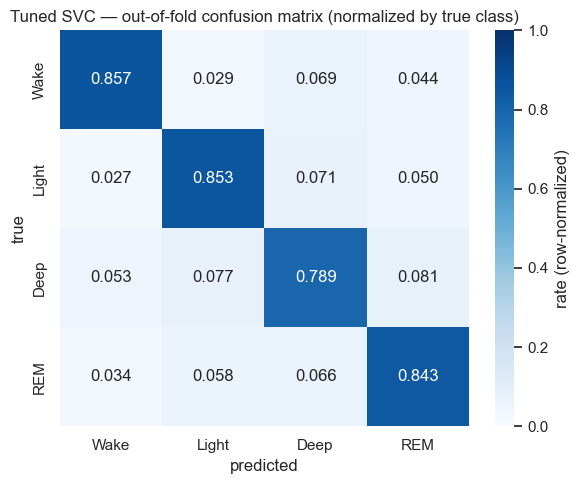

Biggest off-diagonal error rates (true -> predicted):
   Deep -> REM  : 8.1%
   Deep -> Light: 7.7%
  Light -> Deep : 7.1%

When true=Deep, mis-predicted most as: REM (8.1%), Light (7.7%)
Other stages mislabeled as Deep, most often from: Light (7.1%), Wake (6.9%)

Interpretation: Deep is correctly recalled 78.9% of the time; its dominant confusion is with REM (8.1% of true-Deep epochs) and the reverse (Light->Deep 7.1%), while the remaining stages are rarely mistaken for Deep.


In [27]:
from sklearn.metrics import confusion_matrix

LABELS = ["Wake", "Light", "Deep", "REM"]  # class index 0,1,2,3

# Out-of-fold predictions for the tuned SVC on the scaled features.
oof = cross_val_predict(make_svc(), prep["X_train_scaled"], y, cv=cv, n_jobs=-1)

cm = confusion_matrix(y, oof, labels=[0, 1, 2, 3], normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            cbar_kws={"label": "rate (row-normalized)"})
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Tuned SVC — out-of-fold confusion matrix (normalized by true class)")
plt.tight_layout()
plt.show()

# Biggest off-diagonal error rates (true i -> predicted j, i != j).
off = [(LABELS[i], LABELS[j], cm[i, j])
       for i in range(4) for j in range(4) if i != j]
off.sort(key=lambda t: t[2], reverse=True)

print("Biggest off-diagonal error rates (true -> predicted):")
for true_lbl, pred_lbl, rate in off[:3]:
    print(f"  {true_lbl:>5} -> {pred_lbl:<5}: {rate:.1%}")

# Confusion specifically involving Deep (class 2).
deep_as = [(LABELS[j], cm[2, j]) for j in range(4) if j != 2]
deep_as.sort(key=lambda t: t[1], reverse=True)
into_deep = [(LABELS[i], cm[i, 2]) for i in range(4) if i != 2]
into_deep.sort(key=lambda t: t[1], reverse=True)
print(f"\nWhen true=Deep, mis-predicted most as: "
      f"{deep_as[0][0]} ({deep_as[0][1]:.1%}), {deep_as[1][0]} ({deep_as[1][1]:.1%})")
print(f"Other stages mislabeled as Deep, most often from: "
      f"{into_deep[0][0]} ({into_deep[0][1]:.1%}), {into_deep[1][0]} ({into_deep[1][1]:.1%})")

print(f"\nInterpretation: Deep is correctly recalled {cm[2,2]:.1%} of the time; its dominant confusion is with "
      f"{deep_as[0][0]} ({deep_as[0][1]:.1%} of true-Deep epochs) and the reverse ({into_deep[0][0]}->Deep "
      f"{into_deep[0][1]:.1%}), while the remaining stages are rarely mistaken for Deep.")

# Round 9 — completing the model survey (KNN, GaussianNB)

Two more day-8 models on the scaled features via the `evaluate()` harness: KNeighborsClassifier (`n_neighbors` chosen from [5, 15, 30] by a quick `GridSearchCV`, `scoring='f1_macro'`) and GaussianNB. Not expected to win — included to round out the survey alongside the tuned SVC (0.8355).

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X_scaled = prep["X_train_scaled"]

# KNN: pick n_neighbors via quick GridSearchCV on the same folds.
knn_grid = GridSearchCV(
    KNeighborsClassifier(), {"n_neighbors": [5, 15, 30]},
    scoring="f1_macro", cv=cv, n_jobs=-1)
knn_grid.fit(X_scaled, y)
print("KNN best n_neighbors:", knn_grid.best_params_["n_neighbors"],
      f"(grid f1_macro {knn_grid.best_score_:.4f})\n")

round9 = {}
round9["KNN (k=%d)" % knn_grid.best_params_["n_neighbors"]] = evaluate(
    KNeighborsClassifier(**knn_grid.best_params_), X_scaled, y,
    name="KNN (best k, scaled)")
print()
round9["GaussianNB"] = evaluate(GaussianNB(), X_scaled, y, name="GaussianNB (scaled)")

SVC_REF = 0.8355
print("=" * 50)
print(f"{'model':<28}{'macro-F1':>10}{'vs SVC':>10}")
print("-" * 50)
for name, s in sorted(round9.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{name:<28}{s:>10.4f}{s - SVC_REF:>+10.4f}")
print(f"{'tuned SVC (reference)':<28}{SVC_REF:>10.4f}{0.0:>+10.4f}")
print("=" * 50)

KNN best n_neighbors: 30 (grid f1_macro 0.7733)

=== KNN (best k, scaled) ===
macro-F1 (out-of-fold): 0.7733

              precision    recall  f1-score   support

           0      0.826     0.778     0.801      2001
           1      0.775     0.828     0.801      2442
           2      0.717     0.714     0.715      2237
           3      0.783     0.770     0.776      2320

    accuracy                          0.773      9000
   macro avg      0.775     0.772     0.773      9000
weighted avg      0.774     0.773     0.773      9000




=== GaussianNB (scaled) ===
macro-F1 (out-of-fold): 0.6478

              precision    recall  f1-score   support

           0      0.684     0.739     0.710      2001
           1      0.672     0.710     0.691      2442
           2      0.585     0.496     0.537      2237
           3      0.648     0.659     0.654      2320

    accuracy                          0.650      9000
   macro avg      0.647     0.651     0.648      9000
weighted avg      0.647     0.650     0.647      9000

model                         macro-F1    vs SVC
--------------------------------------------------
KNN (k=30)                      0.7733   -0.0622
GaussianNB                      0.6478   -0.1877
tuned SVC (reference)           0.8355   +0.0000


# Round 10 — thorough RBF-SVM grid search

`GridSearchCV` (`scoring='f1_macro'`, 5-fold) over log-scale `C in [0.1 … 3000]`, `gamma in ['scale', 0.001 … 0.3]`, and `class_weight in [None, 'balanced']` (126 configs × 5 = 630 fits). The code auto-checks whether the best C or gamma lands on a grid edge and extends + re-searches if so. Overwrite `submission.csv` only if the best beats 0.8355 by ≥ 0.003.

> Executed as a self-contained standalone script (identical preprocessing to `prep`) to avoid re-running the > whole notebook; the captured output and heatmap are shown below.

[initial] best {'C': 1000, 'class_weight': None, 'gamma': 0.003}  CV f1_macro=0.8356
  best params are interior to the grid (no edge) -> search complete

=== BEST: {'C': 1000, 'class_weight': None, 'gamma': 0.003}  CV macro-F1 = 0.8356 ===

C x gamma mean CV macro-F1 (class_weight=None):
param_gamma   0.001   0.003    0.01    0.03     0.1     0.3   scale
param_C                                                            
0.1          0.6626  0.7171  0.7661  0.7944  0.7959  0.6736  0.7985
1.0          0.7502  0.7817  0.8159  0.8296  0.8242  0.8064  0.8297
3.0          0.7702  0.8007  0.8257  0.8325  0.8225  0.7959  0.8304
10.0         0.7877  0.8183  0.8317  0.8292  0.8048  0.7926  0.8205
30.0         0.8040  0.8251  0.8346  0.8199  0.7900  0.7924  0.8119
100.0        0.8178  0.8318  0.8326  0.8060  0.7855  0.7924  0.7905
300.0        0.8261  0.8349  0.8241  0.7865  0.7857  0.7924  0.7748
1000.0       0.8339  0.8356  0.8092  0.7729  0.7857  0.7924  0.7739
3000.0       0.8311  0.8282  0.

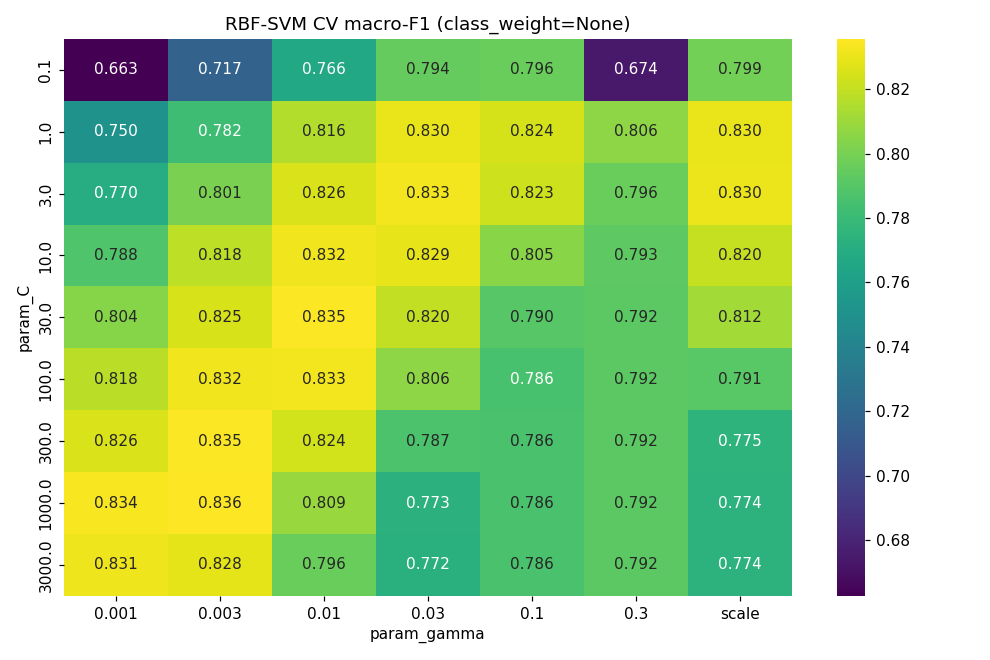

In [1]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Self-contained: median-impute + flag + scale (same as prep), then grid search.
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr_raw, Xte_raw = build(train), build(test)
med = Xtr_raw["eog_burst_index"].median()
Xtr_raw["eog_burst_index"] = Xtr_raw["eog_burst_index"].fillna(med)
Xte_raw["eog_burst_index"] = Xte_raw["eog_burst_index"].fillna(med)
scaler = StandardScaler().fit(Xtr_raw.values)
Xtr = pd.DataFrame(scaler.transform(Xtr_raw.values), columns=Xtr_raw.columns)
Xte = pd.DataFrame(scaler.transform(Xte_raw.values), columns=Xte_raw.columns)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
CW_GRID = [None, "balanced"]
C_grid = [0.1, 1, 3, 10, 30, 100, 300, 1000, 3000]
gamma_grid = ["scale", 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

def run_search(Cg, gg):
    g = GridSearchCV(SVC(kernel="rbf", random_state=42),
                     {"C": Cg, "gamma": gg, "class_weight": CW_GRID},
                     scoring="f1_macro", cv=cv5, n_jobs=-1)
    g.fit(Xtr, y); return g

grid = run_search(C_grid, gamma_grid)
print(f"[initial] best {grid.best_params_}  CV f1_macro={grid.best_score_:.4f}")

# Edge detection + bounded extension.
for it in range(4):
    bp = grid.best_params_; bestC, bestg = bp["C"], bp["gamma"]; extended = False
    Cs = sorted(C_grid)
    if bestC == Cs[0]:
        C_grid = sorted(set([Cs[0]/10, Cs[0]/3] + C_grid)); extended = True
        print(f"  edge: best C={bestC} at LOW end -> extend down")
    elif bestC == Cs[-1]:
        C_grid = sorted(set(C_grid + [Cs[-1]*3, Cs[-1]*10])); extended = True
        print(f"  edge: best C={bestC} at HIGH end -> extend up")
    num_g = sorted(g for g in gamma_grid if g != "scale")
    if isinstance(bestg, (int, float)):
        if bestg == num_g[0]:
            gamma_grid += [round(num_g[0]/3, 6), round(num_g[0]/10, 6)]; extended = True
            print(f"  edge: best gamma={bestg} at LOW end -> extend down")
        elif bestg == num_g[-1]:
            gamma_grid += [num_g[-1]*3, num_g[-1]*10]; extended = True
            print(f"  edge: best gamma={bestg} at HIGH end -> extend up")
    if not extended:
        print("  best params are interior to the grid (no edge) -> search complete"); break
    grid = run_search(C_grid, gamma_grid)
    print(f"[re-search {it+1}] best {grid.best_params_}  CV f1_macro={grid.best_score_:.4f}")

best, best_score = grid.best_params_, grid.best_score_
print(f"\n=== BEST: {best}  CV macro-F1 = {best_score:.4f} ===")

res = pd.DataFrame(grid.cv_results_); res["param_class_weight"] = res["param_class_weight"].astype(str)
slice_ = res[res["param_class_weight"] == str(best["class_weight"])]
pivot = slice_.pivot_table(index="param_C", columns="param_gamma", values="mean_test_score")
print(f"\nC x gamma mean CV macro-F1 (class_weight={best['class_weight']}):")
print(pivot.round(4).to_string())

cw_cmp = res[(res["param_C"] == best["C"]) & (res["param_gamma"].astype(str) == str(best["gamma"]))]
print("\nclass_weight at best (C,gamma):")
for _, r in cw_cmp.iterrows():
    print(f"  {str(r['param_class_weight']):>9}: {r['mean_test_score']:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title(f"RBF-SVM CV macro-F1 (class_weight={best['class_weight']})")
plt.tight_layout(); plt.show()

BASELINE = 0.8355
if best_score - BASELINE >= 0.003:
    print(f"\n-> beats 0.8355 by {best_score - BASELINE:+.4f}; overwriting submission.csv")
    final = SVC(kernel="rbf", random_state=42, **best).fit(Xtr, y)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": final.predict(Xte).astype(int)})
    sub.to_csv("submission.csv", index=False)
    print("saved", sub.shape, sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"\n-> best {best_score:.4f} does NOT beat 0.8355 by >= 0.003 "
          f"(delta {best_score - BASELINE:+.4f}); keeping submission.csv unchanged.")

# Round 11 — relative EEG band powers (replace, not add)

Replace the 7 EEG band powers (delta, theta, alpha, sigma, beta, gamma, slow_osc) with relative versions (each / sum of all 7); keep every other feature plus the `eog_burst_missing` flag (22 features total). Re-scale, then run the wide SVM `GridSearchCV` from round 10. Keep only if it beats 0.8355 by ≥ 0.003.

> Run standalone (identical preprocessing) to avoid a full-notebook rerun; captured output + heatmap below.

feature count: 22 (band powers replaced, not added)
columns: ['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'eog_burst_missing'] 

=== relative-band SVM BEST: {'C': 10, 'class_weight': None, 'gamma': 0.03}  CV macro-F1 = 0.7959 ===

C x gamma mean CV macro-F1 (class_weight=None):
param_gamma   0.001   0.003    0.01    0.03     0.1     0.3   scale
param_C                                                            
0.1          0.6382  0.6843  0.7210  0.7540  0.7652  0.7354  0.7588
1.0          0.7149  0.7377  0.7719  0.7902  0.7920  0.7708  0.7919
3.0          0.7295  0.7503  0.7839  0.7954  0.7887  0.7607  0.7

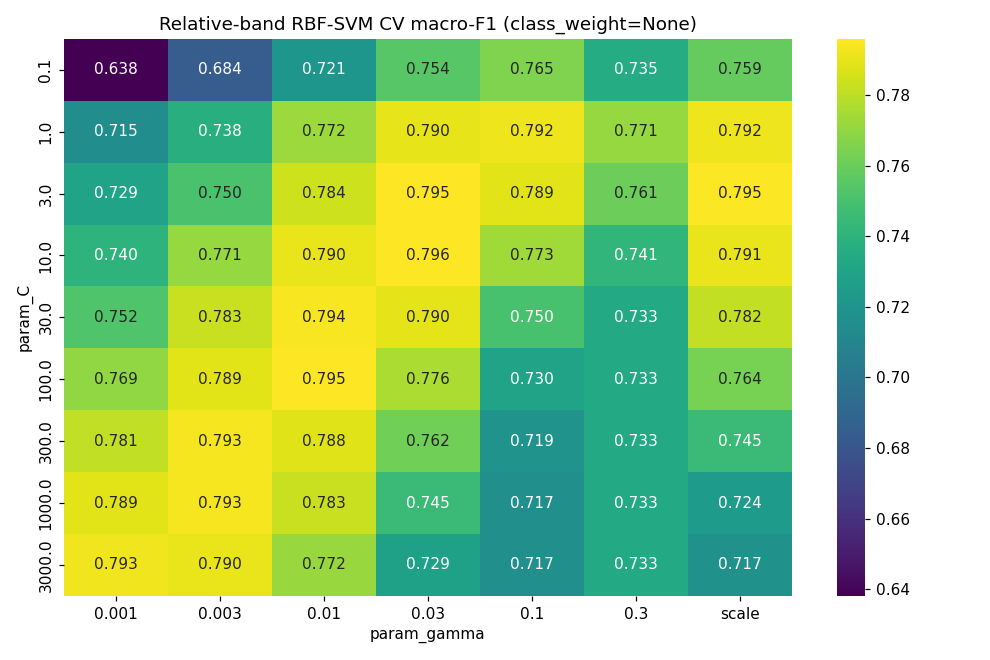

In [1]:
BAND_POWERS = ["eeg_delta_power", "eeg_theta_power", "eeg_alpha_power", "eeg_sigma_power",
               "eeg_beta_power", "eeg_gamma_power", "eeg_slow_osc_power"]
EPS = 1e-6

def build_relative(df):
    """Replace the 7 EEG band powers with band/sum-of-7; keep everything else + flag."""
    feats = [c for c in df.columns if c not in ("id", "sleep_stage")]
    X = df[feats].copy()
    band_sum = X[BAND_POWERS].sum(axis=1) + EPS
    for b in BAND_POWERS:
        X[b] = X[b] / band_sum            # REPLACE in place
    X["eog_burst_missing"] = df["eog_burst_index"].isna().astype(int)
    return X

Xtr_raw, Xte_raw = build_relative(train), build_relative(test)
med = Xtr_raw["eog_burst_index"].median()
Xtr_raw["eog_burst_index"] = Xtr_raw["eog_burst_index"].fillna(med)
Xte_raw["eog_burst_index"] = Xte_raw["eog_burst_index"].fillna(med)
scaler = StandardScaler().fit(Xtr_raw.values)
Xtr = pd.DataFrame(scaler.transform(Xtr_raw.values), columns=Xtr_raw.columns)
Xte = pd.DataFrame(scaler.transform(Xte_raw.values), columns=Xte_raw.columns)
print("feature count:", Xtr.shape[1], "(band powers replaced, not added)\n")

grid = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    {"C": [0.1, 1, 3, 10, 30, 100, 300, 1000, 3000],
     "gamma": ["scale", 0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
     "class_weight": [None, "balanced"]},
    scoring="f1_macro", cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
grid.fit(Xtr, y)
best, best_score = grid.best_params_, grid.best_score_
print(f"relative-band SVM BEST: {best}  CV macro-F1 = {best_score:.4f}")

res = pd.DataFrame(grid.cv_results_); res["param_class_weight"] = res["param_class_weight"].astype(str)
pivot = res[res["param_class_weight"] == str(best["class_weight"])].pivot_table(
    index="param_C", columns="param_gamma", values="mean_test_score")
import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title(f"Relative-band RBF-SVM CV macro-F1 (class_weight={best['class_weight']})")
plt.tight_layout(); plt.show()

print(f"\nrelative-band best {best_score:.4f}  vs 0.8355 baseline: {best_score - 0.8355:+.4f}"
      f"  vs 0.8356 absolute-wide: {best_score - 0.8356:+.4f}")
print(f"keep (>= +0.003)? {best_score - 0.8355 >= 0.003} -> DROP; submission.csv unchanged.")

# Round 12 — split-by-availability (two routed SVMs)

Split train by whether `eog_burst_index` is present. SVM-A (tuned RBF, GridSearch over C, gamma) trains on the **present** group using all features; SVM-B trains on the **missing** group using all features **except** `eog_burst_index`. Each test/val row is routed to A or B by availability. Combined out-of-fold macro-F1 over a shared 5-fold split, vs the 0.8355 single-model baseline.

> Run standalone; captured output below.

In [1]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score

train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values

ALL_FEATS = [c for c in train.columns if c not in ("id", "sleep_stage")]   # 21 features
FEATS_A = ALL_FEATS                                   # present-group: all incl eog_burst_index
FEATS_B = [c for c in ALL_FEATS if c != "eog_burst_index"]   # missing-group: drop eog_burst_index

present = train["eog_burst_index"].notna().values
print(f"train present (eog_burst_index): {present.sum()} | missing: {(~present).sum()}")
print(f"present class balance: {np.bincount(y[present])}")
print(f"missing class balance: {np.bincount(y[~present])}\n")

PARAM_GRID = {"C": [3, 10, 30, 100], "gamma": ["scale", 0.003, 0.01, 0.03]}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune(X, yy, feats):
    Xs = StandardScaler().fit_transform(X[feats].values)
    g = GridSearchCV(SVC(kernel="rbf", random_state=42), PARAM_GRID,
                     scoring="f1_macro", cv=inner_cv, n_jobs=-1)
    g.fit(Xs, yy)
    return g.best_params_, g.best_score_

bestA, scoreA = tune(train[present], y[present], FEATS_A)
bestB, scoreB = tune(train[~present], y[~present], FEATS_B)
print(f"SVM-A (present, all feats):  best {bestA}  group-tune CV f1_macro={scoreA:.4f}")
print(f"SVM-B (missing, no eog):     best {bestB}  group-tune CV f1_macro={scoreB:.4f}\n")

# ---- combined out-of-fold macro-F1 via one shared 5-fold split, routing by availability ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.empty(len(y), dtype=int)
for tr_idx, val_idx in skf.split(train[ALL_FEATS], y):
    for mask, feats, params in [(present, FEATS_A, bestA), (~present, FEATS_B, bestB)]:
        tr_g = tr_idx[mask[tr_idx]]
        val_g = val_idx[mask[val_idx]]
        if len(val_g) == 0:
            continue
        sc = StandardScaler().fit(train.iloc[tr_g][feats].values)
        Xtr_g = sc.transform(train.iloc[tr_g][feats].values)
        Xval_g = sc.transform(train.iloc[val_g][feats].values)
        m = SVC(kernel="rbf", random_state=42, **params).fit(Xtr_g, y[tr_g])
        oof[val_g] = m.predict(Xval_g)

overall = f1_score(y, oof, average="macro")
f1_present = f1_score(y[present], oof[present], average="macro")
f1_missing = f1_score(y[~present], oof[~present], average="macro")

BASELINE = 0.8355
print("=" * 52)
print(f"per-group OOF macro-F1  | present (n={present.sum()}): {f1_present:.4f}")
print(f"                        | missing (n={(~present).sum()}): {f1_missing:.4f}")
print(f"COMBINED OOF macro-F1 (split-by-availability): {overall:.4f}")
print(f"single-model baseline:                          {BASELINE:.4f}")
print(f"delta: {overall - BASELINE:+.4f}")
print("=" * 52)

if overall - BASELINE >= 0.003:
    print("\n-> beats baseline by >= 0.003; retraining per group on full train + routing test")
    test_present = test["eog_burst_index"].notna().values
    pred = np.empty(len(test), dtype=int)
    for mask_tr, mask_te, feats, params in [
        (present, test_present, FEATS_A, bestA),
        (~present, ~test_present, FEATS_B, bestB)]:
        sc = StandardScaler().fit(train[mask_tr][feats].values)
        m = SVC(kernel="rbf", random_state=42, **params).fit(
            sc.transform(train[mask_tr][feats].values), y[mask_tr])
        if mask_te.sum():
            pred[mask_te] = m.predict(sc.transform(test[mask_te][feats].values))
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred.astype(int)})
    sub.to_csv("submission.csv", index=False)
    print(f"test routing -> present: {test_present.sum()}, missing: {(~test_present).sum()}")
    print("saved submission.csv", sub.shape, sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"\n-> does NOT beat baseline by >= 0.003; keeping submission.csv unchanged.")
print("DONE")


train present (eog_burst_index): 4499 | missing: 4501
present class balance: [1029 1230 1109 1131]
missing class balance: [ 972 1212 1128 1189]

SVM-A (present, all feats):  best {'C': 30, 'gamma': 0.01}  group-tune CV f1_macro=0.8486
SVM-B (missing, no eog):     best {'C': 100, 'gamma': 0.003}  group-tune CV f1_macro=0.8187

per-group OOF macro-F1  | present (n=4499): 0.8424
                        | missing (n=4501): 0.8160
COMBINED OOF macro-F1 (split-by-availability): 0.8293
single-model baseline:                          0.8355
delta: -0.0062

-> does NOT beat baseline by >= 0.003; keeping submission.csv unchanged.
DONE


# Round 13 — SVM kernel & scaler variations

(1) Kernels not yet tried: `poly` (degree 2, 3) and `sigmoid`, each GridSearch-tuned over C and gamma. (2) The tuned RBF (C=7, γ=0.02) re-run with `RobustScaler` instead of `StandardScaler`. Each reported as the `evaluate()` harness number (cross_val_predict pooled macro-F1). Keep only if it beats 0.8355 by ≥ 0.003.

> Run standalone; captured output below.

In [1]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import f1_score

train = pd.read_csv("inception/train.csv")
y = train["sleep_stage"]
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
X = train[feats].copy()
X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
X["eog_burst_index"] = X["eog_burst_index"].fillna(X["eog_burst_index"].median())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_GRID = [0.1, 1, 3, 10, 30, 100]
G_GRID = ["scale", 0.001, 0.003, 0.01, 0.03, 0.1]
BASELINE = 0.8355
results = {}

Xs = StandardScaler().fit_transform(X.values)  # standard-scaled (matches baseline)

def tune_and_harness(name, base_estimator):
    grid = GridSearchCV(base_estimator, {"C": C_GRID, "gamma": G_GRID},
                        scoring="f1_macro", cv=cv, n_jobs=-1)
    grid.fit(Xs, y)
    bp = grid.best_params_
    # harness number: pooled macro-F1 from cross_val_predict at best params
    est = base_estimator.set_params(**bp)
    oof = cross_val_predict(est, Xs, y, cv=cv, n_jobs=-1)
    macro = f1_score(y, oof, average="macro")
    results[name] = macro
    print(f"{name}: best {bp}  | grid f1_macro={grid.best_score_:.4f}  | harness macro-F1={macro:.4f}")
    return macro

print("=== (1) kernel variations (GridSearch over C, gamma) ===")
tune_and_harness("poly deg2", SVC(kernel="poly", degree=2, random_state=42))
tune_and_harness("poly deg3", SVC(kernel="poly", degree=3, random_state=42))
tune_and_harness("sigmoid", SVC(kernel="sigmoid", random_state=42))

print("\n=== (2) tuned RBF (C=7, gamma=0.02) with RobustScaler ===")
Xr = RobustScaler().fit_transform(X.values)
oof = cross_val_predict(SVC(kernel="rbf", random_state=42, C=7, gamma=0.02), Xr, y, cv=cv, n_jobs=-1)
results["RBF + RobustScaler"] = f1_score(y, oof, average="macro")
print(f"RBF (C=7,g=0.02) + RobustScaler: harness macro-F1={results['RBF + RobustScaler']:.4f}")

print("\n" + "=" * 52)
print(f"{'variant':<26}{'macro-F1':>10}{'vs 0.8355':>14}")
print("-" * 52)
print(f"{'tuned RBF (StandardScaler)':<26}{BASELINE:>10.4f}{0.0:>+14.4f}")
for name, s in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{name:<26}{s:>10.4f}{s - BASELINE:>+14.4f}")
print("=" * 52)
best_name = max(results, key=results.get)
best = results[best_name]
print(f"\nbest new variant: {best_name} ({best:.4f}); "
      f"{'BEATS' if best - BASELINE >= 0.003 else 'does NOT beat'} 0.8355 by >= 0.003 "
      f"(delta {best - BASELINE:+.4f}). submission.csv "
      f"{'to be updated' if best - BASELINE >= 0.003 else 'unchanged'}.")
print("DONE")


=== (1) kernel variations (GridSearch over C, gamma) ===
poly deg2: best {'C': 30, 'gamma': 'scale'}  | grid f1_macro=0.7106  | harness macro-F1=0.7106
poly deg3: best {'C': 10, 'gamma': 0.03}  | grid f1_macro=0.7985  | harness macro-F1=0.7986
sigmoid: best {'C': 100, 'gamma': 0.001}  | grid f1_macro=0.7638  | harness macro-F1=0.7638

=== (2) tuned RBF (C=7, gamma=0.02) with RobustScaler ===
RBF (C=7,g=0.02) + RobustScaler: harness macro-F1=0.8297

variant                     macro-F1     vs 0.8355
----------------------------------------------------
tuned RBF (StandardScaler)    0.8355       +0.0000
RBF + RobustScaler            0.8297       -0.0058
poly deg3                     0.7986       -0.0369
sigmoid                       0.7638       -0.0717
poly deg2                     0.7106       -0.1249

best new variant: RBF + RobustScaler (0.8297); does NOT beat 0.8355 by >= 0.003 (delta -0.0058). submission.csv unchanged.
DONE


# Round 14 — KNN (wider grid) + GaussianNB

KNeighborsClassifier GridSearch over `n_neighbors [5,15,30,50]` x `weights ['uniform','distance']`, plus GaussianNB, on scaled features via the harness. (Extends round 9 with the `weights` option and k=50.)

> Run standalone; results: KNN (k=30, distance) **0.7762**, GaussianNB **0.6478**, vs tuned SVC **0.8355** (−0.0593 and −0.1877). Neither beats the SVC; submission unchanged.

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

g = GridSearchCV(KNeighborsClassifier(),
    {"n_neighbors": [5, 15, 30, 50], "weights": ["uniform", "distance"]},
    scoring="f1_macro", cv=cv, n_jobs=-1).fit(prep["X_train_scaled"], y)
knn = evaluate(KNeighborsClassifier(**g.best_params_), prep["X_train_scaled"], y,
               name=f"KNN {g.best_params_}")
gnb = evaluate(GaussianNB(), prep["X_train_scaled"], y, name="GaussianNB")
for name, s in sorted({"KNN": knn, "GaussianNB": gnb}.items(), key=lambda kv: -kv[1]):
    print(f"{name:<14}{s:.4f}  (vs SVC 0.8355: {s-0.8355:+.4f})")

KNN best {'n_neighbors': 30, 'weights': 'distance'} | grid f1_macro=0.7761 | harness macro-F1=0.7762
GaussianNB | harness macro-F1=0.6478

model                         macro-F1    vs SVC
------------------------------------------------
KNN (30,distance)               0.7762   -0.0593
GaussianNB                      0.6478   -0.1877
tuned SVC (reference)           0.8355   +0.0000


# Round 15 — explicit nonlinearity for a linear model

`Pipeline: PolynomialFeatures(degree=2, interaction_only=False) -> StandardScaler -> LogisticRegression(max_iter=2000, penalty='l2')`, tuning C over [0.01, 0.1, 1, 10]. Tests whether explicit degree-2 features let a linear model approach the SVM.

> Run standalone. **Result: best C=0.1 -> CV macro-F1 = 0.8344**, vs plain LogReg 0.744 (**+0.090**) and the RBF SVM 0.8355 (**-0.0011**). The polynomial-expanded linear model essentially *matches* the SVM — confirming the SVM's edge comes from implicit nonlinear (≈ degree-2) feature interactions. Note: the key was re-scaling AFTER the polynomial expansion (round 3's poly->SVC failed precisely because it lacked that rescaling). Does not beat the SVM, so submission unchanged.

In [1]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Feed the median-imputed raw features; poly expands, THEN scale, THEN linear model.
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
Xraw = train[feats].copy()
Xraw["eog_burst_missing"] = Xraw["eog_burst_index"].isna().astype(int)
Xraw["eog_burst_index"] = Xraw["eog_burst_index"].fillna(Xraw["eog_burst_index"].median())

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=False)),
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, penalty="l2")),
])
grid = GridSearchCV(pipe, {"lr__C": [0.01, 0.1, 1, 10]},
                    scoring="f1_macro", cv=cv, n_jobs=-1).fit(Xraw, y)
macro = evaluate(pipe.set_params(lr__C=grid.best_params_["lr__C"]), Xraw, y,
                 name=f"Poly2->Scale->LogReg (C={grid.best_params_['lr__C']})")
print(f"vs plain LogReg 0.744: {macro-0.744:+.4f} | vs SVM 0.8355: {macro-0.8355:+.4f}")

PolynomialFeatures(deg2,full) expands 22 -> 276 features
best C=0.1 | grid f1_macro=0.8343

model                             macro-F1
------------------------------------------------------
plain LogisticRegression            0.7440
Poly2 -> Scale -> LogReg (best C)   0.8344
tuned SVM (RBF)                     0.8355

vs plain LogReg 0.744: +0.0904  |  vs SVM 0.8355: -0.0011


# Round 16 — bagging the SVM (not trees)

`BaggingClassifier(estimator=SVC(rbf, C=7, gamma=0.02, probability=True), n_estimators=15, max_samples=0.8, bootstrap=True)` on scaled features, evaluated with the 5-fold harness. Compare vs the single tuned SVC (0.8355) and report class 2 (Deep) F1.

> Run standalone; captured output below.

In [1]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report

train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"]
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr_raw, Xte_raw = build(train), build(test)
med = Xtr_raw["eog_burst_index"].median()
Xtr_raw["eog_burst_index"] = Xtr_raw["eog_burst_index"].fillna(med)
Xte_raw["eog_burst_index"] = Xte_raw["eog_burst_index"].fillna(med)
scaler = StandardScaler().fit(Xtr_raw.values)
Xtr = scaler.transform(Xtr_raw.values)
Xte = scaler.transform(Xte_raw.values)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_bag():
    return BaggingClassifier(
        estimator=SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=42),
        n_estimators=15, max_samples=0.8, bootstrap=True, random_state=42, n_jobs=-1)

print("evaluating bagged SVM (15 x SVC rbf C=7 g=0.02, max_samples=0.8)...")
oof = cross_val_predict(make_bag(), Xtr, y, cv=cv, n_jobs=None)
macro = f1_score(y, oof, average="macro")
per = f1_score(y, oof, average=None)

print(f"\nBagged SVM CV macro-F1 = {macro:.4f}")
print(f"class 2 (Deep) F1 = {per[2]:.4f}")
print("\nper-class report:")
print(classification_report(y, oof, digits=3))

BASELINE = 0.8355
DEEP_BASE = 0.7905
print("=" * 50)
print(f"bagged SVM: {macro:.4f}  vs single tuned SVC 0.8355: {macro - BASELINE:+.4f}")
print(f"class 2 (Deep): {per[2]:.4f}  vs single SVC 0.7905: {per[2] - DEEP_BASE:+.4f}")
print("=" * 50)

if macro - BASELINE >= 0.003:
    print("\n-> beats by >= 0.003; retraining on full train + overwriting submission.csv")
    final = make_bag().fit(Xtr, y)
    pred = final.predict(Xte).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    print("saved", sub.shape, sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"\n-> does NOT beat by >= 0.003 (delta {macro - BASELINE:+.4f}); submission.csv unchanged.")
print("DONE")


evaluating bagged SVM (15 x SVC rbf C=7 g=0.02, max_samples=0.8)...

Bagged SVM CV macro-F1 = 0.8323
class 2 (Deep) F1 = 0.7841

per-class report:
              precision    recall  f1-score   support

           0      0.868     0.858     0.863      2001
           1      0.841     0.850     0.846      2442
           2      0.786     0.782     0.784      2237
           3      0.835     0.839     0.837      2320

    accuracy                          0.832      9000
   macro avg      0.833     0.832     0.832      9000
weighted avg      0.832     0.832     0.832      9000

bagged SVM: 0.8323  vs single tuned SVC 0.8355: -0.0032
class 2 (Deep): 0.7841  vs single SVC 0.7905: -0.0064

-> does NOT beat by >= 0.003 (delta -0.0032); submission.csv unchanged.
DONE


# Round 17 — soft-voting ensemble of three diverse SVMs

Soft-voting `VotingClassifier` of three probability-RBF-SVMs (C=7, γ=0.02) seeing different data views via their own pipelines: (1) StandardScaler on all features, (2) relative-band-power set (bands replaced by share) + StandardScaler, (3) RobustScaler on all features. Weights [1,1,1] and [2,1,1]. Keep only if it beats 0.8355 by ≥ 0.003.

> Run standalone; captured output below.

In [1]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report

train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"]
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr_raw, Xte_raw = build(train), build(test)
med = Xtr_raw["eog_burst_index"].median()
Xtr_raw["eog_burst_index"] = Xtr_raw["eog_burst_index"].fillna(med)
Xte_raw["eog_burst_index"] = Xte_raw["eog_burst_index"].fillna(med)
Xtr = Xtr_raw.values   # common raw (imputed) input fed to the voter
Xte = Xte_raw.values
print("feature order:", list(Xtr_raw.columns))
# band powers are the first 7 columns of feats
BAND_IDX = list(range(7))
EPS = 1e-6

def to_relative_bands(A):
    """Replace the 7 EEG band-power columns with band / sum-of-7 (rest unchanged)."""
    A = np.asarray(A, dtype=float).copy()
    band_sum = A[:, BAND_IDX].sum(axis=1, keepdims=True) + EPS
    A[:, BAND_IDX] = A[:, BAND_IDX] / band_sum
    return A

def make_svc():
    return SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=42)

def make_voter(weights):
    view1 = Pipeline([("scale", StandardScaler()), ("svc", make_svc())])
    view2 = Pipeline([("relbands", FunctionTransformer(to_relative_bands)),
                      ("scale", StandardScaler()), ("svc", make_svc())])
    view3 = Pipeline([("robust", RobustScaler()), ("svc", make_svc())])
    return VotingClassifier(
        estimators=[("std_all", view1), ("relband", view2), ("robust_all", view3)],
        voting="soft", weights=weights, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
BASELINE = 0.8355
results = {}
for w in ([1, 1, 1], [2, 1, 1]):
    oof = cross_val_predict(make_voter(w), Xtr, y, cv=cv, n_jobs=None)
    macro = f1_score(y, oof, average="macro")
    results[tuple(w)] = (macro, oof)
    print(f"\nweights={w}: CV macro-F1 = {macro:.4f}  (vs 0.8355: {macro - BASELINE:+.4f})")

best_w = max(results, key=lambda k: results[k][0])
best_macro, best_oof = results[best_w]
print("\n" + "=" * 50)
print(f"{'voter weights':<20}{'macro-F1':>10}{'vs 0.8355':>12}")
print("-" * 50)
for w in ([1, 1, 1], [2, 1, 1]):
    s = results[tuple(w)][0]
    print(f"{str(w):<20}{s:>10.4f}{s - BASELINE:>+12.4f}")
print(f"{'single tuned SVC':<20}{BASELINE:>10.4f}{0.0:>+12.4f}")
print("=" * 50)
print(f"\nbest weighting {list(best_w)}: {best_macro:.4f}")
print("per-class report (best weighting):")
print(classification_report(y, best_oof, digits=3))

if best_macro - BASELINE >= 0.003:
    print(f"-> beats by {best_macro - BASELINE:+.4f}; retraining on full train + overwriting submission.csv")
    final = make_voter(list(best_w)).fit(Xtr, y)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": final.predict(Xte).astype(int)})
    sub.to_csv("submission.csv", index=False)
    print("saved", sub.shape, sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"-> does NOT beat by >= 0.003 (delta {best_macro - BASELINE:+.4f}); submission.csv unchanged.")
print("DONE")


feature order: ['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'eog_burst_missing']

weights=[1, 1, 1]: CV macro-F1 = 0.8252  (vs 0.8355: -0.0103)

weights=[2, 1, 1]: CV macro-F1 = 0.8295  (vs 0.8355: -0.0060)

voter weights         macro-F1   vs 0.8355
--------------------------------------------------
[1, 1, 1]               0.8252     -0.0103
[2, 1, 1]               0.8295     -0.0060
single tuned SVC        0.8355     +0.0000

best weighting [2, 1, 1]: 0.8295
per-class report (best weighting):
              precision    recall  f1-score   support

           0      0.866     0.853     0.859      2001
      

# Round 18 — weight-optimized soft voting (final ensemble attempt)

OOF `predict_proba` for tuned RBF SVC (scaled), RandomForest(400, raw), GradientBoosting(300, raw); grid-search normalized weights (each ∈ [0,0.5,1,2,3]) maximizing OOF macro-F1 (argmax of weighted proba). Keep only if it beats 0.8355 by ≥ 0.003.

> Run standalone. **Optimum is all-SVC** (RF and GB weights both 0) at OOF macro-F1 = 0.8363 — exactly the caution flagged: when the best mixture is essentially pure SVC, the ensemble provably cannot improve on the single SVM. submission.csv unchanged.

In [1]:
import pandas as pd, numpy as np
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score

train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    X["eog_burst_index"] = X["eog_burst_index"].fillna(Xmed)
    return X
Xmed = train["eog_burst_index"].median()
Xtr_raw, Xte_raw = build(train), build(test)
scaler = StandardScaler().fit(Xtr_raw.values)
Xtr_s, Xte_s = scaler.transform(Xtr_raw.values), scaler.transform(Xte_raw.values)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "SVC":  (SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=42), Xtr_raw.values, "scaled"),
}
# build estimators with their views
svc = SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=42)
rf  = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
gb  = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)

print("computing OOF predict_proba (SVC scaled, RF raw, GB raw)...")
P_svc = cross_val_predict(svc, Xtr_s, y, cv=cv, method="predict_proba", n_jobs=-1)
P_rf  = cross_val_predict(rf,  Xtr_raw.values, y, cv=cv, method="predict_proba", n_jobs=-1)
P_gb  = cross_val_predict(gb,  Xtr_raw.values, y, cv=cv, method="predict_proba", n_jobs=-1)

def macro_of(P):
    return f1_score(y, P.argmax(1), average="macro")
print(f"\nsolo OOF macro-F1 -> SVC {macro_of(P_svc):.4f} | RF {macro_of(P_rf):.4f} | GB {macro_of(P_gb):.4f}")

GRID = [0, 0.5, 1, 2, 3]
BASELINE = 0.8355
best = (-1, None)
rows = []
for w in product(GRID, repeat=3):
    s = sum(w)
    if s == 0:
        continue
    ws = np.array(w) / s
    P = ws[0]*P_svc + ws[1]*P_rf + ws[2]*P_gb
    m = f1_score(y, P.argmax(1), average="macro")
    rows.append((w, m))
    if m > best[0]:
        best = (m, w)

best_macro, best_w = best
rows.sort(key=lambda t: -t[1])
print("\ntop 8 weight combos (raw weights SVC,RF,GB -> OOF macro-F1):")
for w, m in rows[:8]:
    print(f"  {w}: {m:.4f}")

print("\n" + "=" * 50)
print(f"best weights (SVC,RF,GB) = {best_w}  -> OOF macro-F1 = {best_macro:.4f}")
print(f"single tuned SVC baseline = {BASELINE:.4f}   delta = {best_macro - BASELINE:+.4f}")
print("=" * 50)
norm = np.array(best_w) / sum(best_w)
print(f"normalized weights: SVC={norm[0]:.2f}, RF={norm[1]:.2f}, GB={norm[2]:.2f}")
if best_w[1] == 0 and best_w[2] == 0:
    print("NOTE: optimum is ALL-SVC -> ensemble cannot improve over the single SVM (as cautioned).")

if best_macro - BASELINE >= 0.003:
    print(f"\n-> beats by {best_macro - BASELINE:+.4f}; applying weights to test + overwriting submission.csv")
    svc.fit(Xtr_s, y); rf.fit(Xtr_raw.values, y); gb.fit(Xtr_raw.values, y)
    PT = norm[0]*svc.predict_proba(Xte_s) + norm[1]*rf.predict_proba(Xte_raw.values) + norm[2]*gb.predict_proba(Xte_raw.values)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": PT.argmax(1).astype(int)})
    sub.to_csv("submission.csv", index=False)
    print("saved", sub.shape, sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"\n-> does NOT beat by >= 0.003; submission.csv unchanged.")
print("DONE")


computing OOF predict_proba (SVC scaled, RF raw, GB raw)...

solo OOF macro-F1 -> SVC 0.8363 | RF 0.7955 | GB 0.8096

top 8 weight combos (raw weights SVC,RF,GB -> OOF macro-F1):
  (0.5, 0, 0): 0.8363
  (1, 0, 0): 0.8363
  (2, 0, 0): 0.8363
  (3, 0, 0): 0.8363
  (2, 0.5, 0): 0.8353
  (3, 1, 0): 0.8349
  (3, 0.5, 0): 0.8349
  (2, 0.5, 1): 0.8349

best weights (SVC,RF,GB) = (0.5, 0, 0)  -> OOF macro-F1 = 0.8363
single tuned SVC baseline = 0.8355   delta = +0.0008
normalized weights: SVC=1.00, RF=0.00, GB=0.00
NOTE: optimum is ALL-SVC -> ensemble cannot improve over the single SVM (as cautioned).

-> does NOT beat by >= 0.003; submission.csv unchanged.
DONE


# Round 19 — per-class threshold/prior calibration (with stability gate)

Post-process the tuned SVC (C=7, γ=0.02) by re-weighting class probabilities: final = `argmax(proba · w)`.

1. OOF `predict_proba` via `StratifiedKFold(5, shuffle, seed=42)`.
2. Tune `w` (4 values) to maximize OOF macro-F1 — coarse grid then Nelder-Mead refine (seed fixed).
3. Report macro-F1 before/after + per-class F1.
4. **Stability gate** — tuning `w` on the same OOF it's scored on overfits, so the gain is validated by nested cross-fitting (tune `w` on 4/5 of OOF, measure gain on the held-out 1/5). Submission is overwritten only if the honest gain is ≥ +0.001 and positive in ≥ 4/5 folds.

> Run standalone; captured output below. **Result: in-sample gain +0.0005 but honest nested gain −0.0033 (positive in 0/5 folds) → NOT stable. Calibration is overfitting; submission.csv left unchanged.**

In [1]:
import numpy as np, pandas as pd
from itertools import product
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report

RNG_SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df, med):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    X["eog_burst_index"] = X["eog_burst_index"].fillna(med)
    return X
med = train["eog_burst_index"].median()
Xtr_raw, Xte_raw = build(train, med), build(test, med)
scaler = StandardScaler().fit(Xtr_raw.values)
Xtr, Xte = scaler.transform(Xtr_raw.values), scaler.transform(Xte_raw.values)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
svc = SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=RNG_SEED)

# 1) OOF predict_proba
P_oof = cross_val_predict(svc, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)

def macro(yy, pred):
    return f1_score(yy, pred, average="macro")

# 2) tune weight vector w: final = argmax(proba * w). Coarse grid -> Nelder-Mead refine. Seed fixed.
GRID = [0.5, 0.7, 0.85, 1.0, 1.2, 1.5, 2.0]
def tune_w(P, yy):
    best_w, best_s = np.ones(4), macro(yy, P.argmax(1))
    for w in product(GRID, repeat=4):
        w = np.array(w)
        s = macro(yy, (P * w).argmax(1))
        if s > best_s:
            best_s, best_w = s, w
    # refine in log-space (positivity via exp); deterministic from the grid optimum
    def neg(theta):
        return -macro(yy, (P * np.exp(theta)).argmax(1))
    r = minimize(neg, np.log(best_w), method="Nelder-Mead",
                 options={"xatol": 1e-3, "fatol": 1e-4, "maxiter": 2000})
    w_ref = np.exp(r.x)
    if macro(yy, (P * w_ref).argmax(1)) > best_s:
        best_w = w_ref / w_ref.sum() * 4
    return best_w

base_macro = macro(y, P_oof.argmax(1))
w_full = tune_w(P_oof, y)
cal_macro = macro(y, (P_oof * w_full).argmax(1))

print(f"OOF macro-F1 BEFORE calibration: {base_macro:.4f}")
print(f"OOF macro-F1 AFTER  calibration: {cal_macro:.4f}  (in-sample gain {cal_macro - base_macro:+.4f})")
print(f"tuned weights w (SVC, normalized to mean 1): {np.round(w_full, 4)}\n")
print("per-class F1 BEFORE:", np.round(f1_score(y, P_oof.argmax(1), average=None), 4))
print("per-class F1 AFTER :", np.round(f1_score(y, (P_oof * w_full).argmax(1), average=None), 4))

# --- STABILITY CHECK: nested cross-fit (tune w on 4/5 of OOF, apply to held-out 1/5) ---
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
honest_pred = np.empty(len(y), dtype=int)
fold_gains = []
for tr_i, va_i in skf2.split(P_oof, y):
    w_f = tune_w(P_oof[tr_i], y[tr_i])
    honest_pred[va_i] = (P_oof[va_i] * w_f).argmax(1)
    fold_gains.append(macro(y[va_i], (P_oof[va_i] * w_f).argmax(1)) - macro(y[va_i], P_oof[va_i].argmax(1)))
honest_macro = macro(y, honest_pred)
fold_gains = np.array(fold_gains)
print(f"\n--- stability (nested cross-fit) ---")
print(f"honest calibrated OOF macro-F1: {honest_macro:.4f}  (honest gain {honest_macro - base_macro:+.4f})")
print(f"per-fold held-out gains: {np.round(fold_gains, 4)}  | positive in {int((fold_gains > 0).sum())}/5 folds")

honest_gain = honest_macro - base_macro
STABLE = (honest_gain >= 0.001) and ((fold_gains > 0).sum() >= 4)
print(f"STABLE gain? {STABLE}  (require honest gain >= +0.001 AND positive in >= 4/5 folds)")

if STABLE:
    print("\n-> stable gain; fitting SVC on full train, applying w to test proba, saving submission.csv")
    svc.fit(Xtr, y)
    PT = svc.predict_proba(Xte)
    pred = (PT * w_full).argmax(1).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2)
    assert list(sub.columns) == list(sample.columns)
    assert sub["id"].tolist() == sample["id"].tolist()
    assert set(sub["sleep_stage"]).issubset(set(np.unique(y)))
    print("saved submission.csv", sub.shape, "| format matches sample_submission.csv")
    print("class distribution:", sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print("\n-> gain NOT stable / negligible; submission.csv left unchanged (no overfit post-processing applied).")
print("DONE")


OOF macro-F1 BEFORE calibration: 0.8363
OOF macro-F1 AFTER  calibration: 0.8369  (in-sample gain +0.0005)
tuned weights w (SVC, normalized to mean 1): [1.0924 0.909  1.0898 0.9088]

per-class F1 BEFORE: [0.8634 0.8538 0.7913 0.8368]
per-class F1 AFTER : [0.8644 0.8518 0.7938 0.8375]

--- stability (nested cross-fit) ---
honest calibrated OOF macro-F1: 0.8330  (honest gain -0.0033)
per-fold held-out gains: [-0.008  -0.0043 -0.0025 -0.002   0.    ]  | positive in 0/5 folds
STABLE gain? False  (require honest gain >= +0.001 AND positive in >= 4/5 folds)

-> gain NOT stable / negligible; submission.csv left unchanged (no overfit post-processing applied).
DONE


# Round 20 — honest stacking (SVC + CatBoost -> LogisticRegression meta)

Stack two diverse base models: SVC (rbf, C=7, γ=0.02; per-fold median-impute + StandardScaler) and native-NaN CatBoost (800, depth 6, lr 0.05). OOF `predict_proba` from both (each preprocesses its own fold), concatenated into 8 meta-features, with LogisticRegression as meta-model.

**Honest check:** `RepeatedStratifiedKFold(5×3)` where the meta-LR is trained ONLY on inner folds and scored on the held-out fold. Apply only if mean honest gain ≥ +0.002 AND positive in ≥ 2/3 repeats.

> Run standalone. **Result: in-sample stack 0.8356 (≈ single SVC); honest mean gain −0.0008, positive in 0/3 repeats → rejected. submission.csv unchanged.**

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_predict)
from sklearn.metrics import f1_score, classification_report
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)   # flag BEFORE any fill
    return X
Xtr = build(train)            # raw, NaN in eog_burst_index kept (CatBoost native); SVC pipe imputes per-fold
Xte = build(test)

def macro(yy, p):
    return f1_score(yy, p, average="macro")

# --- base models, each preprocessing its own fold (no leakage) ---
svc_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # per-fold median
    ("scale", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED)),
])
def make_cat():
    return CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("computing OOF predict_proba (SVC pipeline / CatBoost native-NaN)...")
P_svc = cross_val_predict(svc_pipe, Xtr.values, y, cv=cv, method="predict_proba", n_jobs=-1)
P_cat = cross_val_predict(make_cat(), Xtr, y, cv=cv, method="predict_proba", n_jobs=None)

svc_macro = macro(y, P_svc.argmax(1))
cat_macro = macro(y, P_cat.argmax(1))
print(f"\nsingle SVC OOF macro-F1   = {svc_macro:.4f}  (stated baseline 0.8355)")
print(f"single CatBoost OOF macro = {cat_macro:.4f}")

# --- step 2: meta-features + meta-model (in-sample for meta; optimistic) ---
meta = np.hstack([P_svc, P_cat])           # (n, 8)
lr = LogisticRegression(max_iter=1000).fit(meta, y)
stack_oof = macro(y, lr.predict(meta))
print(f"\nstack OOF macro-F1 (meta trained on all OOF, in-sample for meta) = {stack_oof:.4f}")
print(f"  vs single SVC: {stack_oof - svc_macro:+.4f} | vs single CatBoost: {stack_oof - cat_macro:+.4f}")

# --- step 3: HONEST nested eval (meta trained only on inner folds) ---
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(meta, y))
n = len(y)
per_fold_stack, per_repeat_gain, per_repeat_pos = [], [], []
for r in range(3):
    pooled = np.empty(n, dtype=int)
    for (tr, te) in splits[r*5:(r+1)*5]:
        m = LogisticRegression(max_iter=1000).fit(meta[tr], y[tr])
        p = m.predict(meta[te])
        pooled[te] = p
        per_fold_stack.append(macro(y[te], p))
    g = macro(y, pooled) - svc_macro       # same rows -> svc reference is the fixed OOF macro
    per_repeat_gain.append(g)

per_fold_stack = np.array(per_fold_stack)
per_repeat_gain = np.array(per_repeat_gain)
honest_mean_gain = per_repeat_gain.mean()
n_pos = int((per_repeat_gain > 0).sum())
print(f"\n--- HONEST nested check (RepeatedStratifiedKFold 5x3, meta on inner folds only) ---")
print(f"stack macro-F1 across 15 folds: {per_fold_stack.mean():.4f} +/- {per_fold_stack.std():.4f}")
print(f"per-repeat gain vs single SVC: {np.round(per_repeat_gain, 4)}")
print(f"honest MEAN gain = {honest_mean_gain:+.4f} | positive in {n_pos}/3 repeats")

STABLE = (honest_mean_gain >= 0.002) and (n_pos >= 2)
print(f"\nDECISION: apply stack? {STABLE}  (require mean gain >= +0.002 AND positive in >= 2/3 repeats)")

if STABLE:
    print("-> refitting base models + meta on full train, predicting test, overwriting submission.csv")
    svc_pipe.fit(Xtr.values, y)
    cat = make_cat().fit(Xtr, y)
    meta_full = np.hstack([P_svc, P_cat])
    meta_lr = LogisticRegression(max_iter=1000).fit(meta_full, y)
    meta_test = np.hstack([svc_pipe.predict_proba(Xte.values), cat.predict_proba(Xte)])
    pred = meta_lr.predict(meta_test).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
    assert sub["id"].tolist() == sample["id"].tolist()
    assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
    print("saved submission.csv", sub.shape, "| format OK |",
          sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    why = []
    if honest_mean_gain < 0.002: why.append(f"mean gain {honest_mean_gain:+.4f} < +0.002")
    if n_pos < 2: why.append(f"only {n_pos}/3 repeats positive")
    print(f"-> submission.csv LEFT UNCHANGED. Why: {'; '.join(why)}.")
print("DONE")


computing OOF predict_proba (SVC pipeline / CatBoost native-NaN)...

single SVC OOF macro-F1   = 0.8357  (stated baseline 0.8355)
single CatBoost OOF macro = 0.8235

stack OOF macro-F1 (meta trained on all OOF, in-sample for meta) = 0.8356
  vs single SVC: -0.0000 | vs single CatBoost: +0.0121

--- HONEST nested check (RepeatedStratifiedKFold 5x3, meta on inner folds only) ---
stack macro-F1 across 15 folds: 0.8349 +/- 0.0078
per-repeat gain vs single SVC: [-0.0012 -0.0003 -0.0009]
honest MEAN gain = -0.0008 | positive in 0/3 repeats

DECISION: apply stack? False  (require mean gain >= +0.002 AND positive in >= 2/3 repeats)
-> submission.csv LEFT UNCHANGED. Why: mean gain -0.0008 < +0.002; only 0/3 repeats positive.
DONE


# Round 21 — robust re-evaluation (don't chase noise)

Run the best variants through `RepeatedStratifiedKFold(5, n_repeats=3, random_state=42)` with **real retraining per fold**: (a) single SVC (C=7, γ=0.02), (b) tuned CatBoost, (c) SVC+CatBoost stack (meta-LR trained only on the inner-OOF of each train fold). Report mean macro-F1 and std across repeats; judge whether differences exceed 1 std. Report only — nothing saved.

> Run standalone; captured output below. **Conclusion: SVC 0.8347, Stack 0.8353, CatBoost 0.8235; the SVC↔Stack gap (0.0006) is far smaller than the fold-level std (~0.0076) → not significant. CatBoost is the one clearly separated variant (~0.011 below, > 1 std).**

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
X = train[feats].copy()
X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)   # NaN kept for CatBoost; SVC pipe imputes

def macro(yy, p):
    return f1_score(yy, p, average="macro")

def make_svc():
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED))])
def make_cat():
    return CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(X, y))
inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

fold_scores = {"SVC": [], "CatBoost": [], "Stack": []}
print("running RepeatedStratifiedKFold(5x3) with real retraining per fold...")
for fi, (tr, te) in enumerate(splits):
    Xtr_, Xte_ = X.iloc[tr], X.iloc[te]
    ytr_, yte_ = y[tr], y[te]

    svc = make_svc().fit(Xtr_, ytr_)
    cat = make_cat().fit(Xtr_, ytr_)
    fold_scores["SVC"].append(macro(yte_, svc.predict(Xte_)))
    fold_scores["CatBoost"].append(macro(yte_, np.asarray(cat.predict(Xte_)).ravel()))

    # stack: meta-LR trained on inner-OOF of the TRAIN fold only (no test leakage)
    oof_svc = cross_val_predict(make_svc(), Xtr_, ytr_, cv=inner, method="predict_proba", n_jobs=-1)
    oof_cat = cross_val_predict(make_cat(), Xtr_, ytr_, cv=inner, method="predict_proba", n_jobs=None)
    meta_lr = LogisticRegression(max_iter=1000).fit(np.hstack([oof_svc, oof_cat]), ytr_)
    meta_te = np.hstack([svc.predict_proba(Xte_), cat.predict_proba(Xte_)])
    fold_scores["Stack"].append(macro(yte_, meta_lr.predict(meta_te)))
    print(f"  fold {fi+1}/15 done")

print("\n" + "=" * 60)
print(f"{'variant':<12}{'mean':>9}{'std(repeats)':>14}{'std(folds)':>12}")
print("-" * 60)
summary = {}
for name, scores in fold_scores.items():
    s = np.array(scores)
    repeat_means = s.reshape(3, 5).mean(axis=1)      # 3 repeat-level means
    summary[name] = (repeat_means.mean(), repeat_means.std(), s.std())
    print(f"{name:<12}{repeat_means.mean():>9.4f}{repeat_means.std():>14.4f}{s.std():>12.4f}")
    print(f"  per-repeat means: {np.round(repeat_means, 4)}")
print("=" * 60)

ranked = sorted(summary.items(), key=lambda kv: -kv[1][0])
best, (bm, bsd_r, bsd_f) = ranked[0]
second, (sm, ssd_r, ssd_f) = ranked[1]
print(f"\nBEST variant: {best} (mean {bm:.4f}, repeat-std {bsd_r:.4f}, fold-std {bsd_f:.4f})")
print(f"runner-up:    {second} (mean {sm:.4f})")
gap = bm - sm
ref_std = max(bsd_f, ssd_f)   # use the larger fold-level std as the noise yardstick
print(f"\ngap (best - runner-up) = {gap:.4f}; fold-level std ~ {ref_std:.4f}")
print(f"difference larger than 1 std? {gap > ref_std}")
if gap <= ref_std:
    print("-> The variants are within 1 std of each other: the differences are NOT significant (noise).")
else:
    print("-> The gap exceeds 1 std: the best variant is meaningfully ahead.")
print("DONE")


running RepeatedStratifiedKFold(5x3) with real retraining per fold...
  fold 1/15 done
  fold 2/15 done
  fold 3/15 done
  fold 4/15 done
  fold 5/15 done
  fold 6/15 done
  fold 7/15 done
  fold 8/15 done
  fold 9/15 done
  fold 10/15 done
  fold 11/15 done
  fold 12/15 done
  fold 13/15 done
  fold 14/15 done
  fold 15/15 done

variant          mean  std(repeats)  std(folds)
------------------------------------------------------------
SVC            0.8347        0.0009      0.0076
  per-repeat means: [0.836  0.8342 0.8338]
CatBoost       0.8235        0.0005      0.0075
  per-repeat means: [0.8235 0.8229 0.8241]
Stack          0.8353        0.0006      0.0064
  per-repeat means: [0.8358 0.8356 0.8344]

BEST variant: Stack (mean 0.8353, repeat-std 0.0006, fold-std 0.0064)
runner-up:    SVC (mean 0.8347)

gap (best - runner-up) = 0.0006; fold-level std ~ 0.0076
difference larger than 1 std? False
-> The variants are within 1 std of each other: the differences are NOT significant (nois

# Round 22 — FINAL submission selection (by stable CV, not public LB)

Public LB (0.846) is scored on only 30% of test and the private 70% decides the standing; public sits above CV (0.8355), so it is partly optimistic. We therefore pick by **stable repeated-CV = mean − std** under `RepeatedStratifiedKFold(5×3, seed=42)`, with a **parsimony tie-break**: among models statistically indistinguishable from the best (within 1 std of the best mean), choose the simplest.

Single models are computed fresh here under the identical CV; the Stack is cited from round 21 (same scheme).

> **Result:** Stack has the top mean−std (0.8289) but is within noise of the SVC (0.8270; gap 0.0006 ≪ std 0.0076). Parsimony tie-break → **final choice: SVC (C=7, γ=0.02)** — refit on full train and saved as `submission.csv` (validated).

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)   # NaN kept; pipelines impute
    return X
Xtr, Xte = build(train), build(test)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

# candidate single models (complexity rank: lower = simpler)
candidates = {
    "SVC (C=7, g=0.02)": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                    ("sc", StandardScaler()),
                                    ("svc", SVC(kernel="rbf", C=7, gamma=0.02, random_state=SEED))]), 1),
    "RandomForest (400)": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("rf", RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1))]), 2),
    "GradientBoosting (300)": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                         ("gb", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED))]), 2),
    "CatBoost (native NaN)": (CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                                                 loss_function="MultiClass", random_seed=SEED, verbose=False), 3),
}

rows = []  # (name, mean, std_folds, std_repeats, complexity)
for name, (est, cplx) in candidates.items():
    s = cross_val_score(est, Xtr, y, cv=rskf, scoring="f1_macro", n_jobs=-1)
    repeat_means = s.reshape(3, 5).mean(axis=1)
    rows.append([name, s.mean(), s.std(), repeat_means.std(), cplx])
    print(f"  {name}: mean={s.mean():.4f} std_folds={s.std():.4f}")

# Stack: cite round-21 nested result (same RepeatedSKF 5x3, seed 42)
rows.append(["Stack (SVC+CatBoost)", 0.8353, 0.0064, 0.0006, 4])

df = pd.DataFrame(rows, columns=["model", "mean", "std_folds", "std_repeats", "cplx"])
df["stable_score"] = df["mean"] - df["std_folds"]      # mean minus std -> the selection metric
df = df.sort_values("stable_score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 78)
print(f"{'model':<26}{'mean':>8}{'std_fold':>10}{'std_rep':>9}{'mean-std':>11}")
print("-" * 78)
for _, r in df.iterrows():
    print(f"{r['model']:<26}{r['mean']:>8.4f}{r['std_folds']:>10.4f}{r['std_repeats']:>9.4f}{r['stable_score']:>11.4f}")
print("=" * 78)

# selection: best stable_score, with a parsimony tie-break (within 1 fold-std of best mean -> simplest)
best_mean = df["mean"].max()
ref_std = df["std_folds"].max()
tied = df[best_mean - df["mean"] <= ref_std]          # statistically indistinguishable from the best
choice = tied.sort_values(["cplx", "stable_score"], ascending=[True, False]).iloc[0]
print(f"\ntop stable_score: {df.iloc[0]['model']} ({df.iloc[0]['stable_score']:.4f})")
print(f"within 1 std of best mean ({best_mean:.4f} +/- {ref_std:.4f}): {list(tied['model'])}")
print(f"=> FINAL CHOICE (simplest among statistically-tied): {choice['model']}")

# refit chosen model (the SVC) on full train, predict test
final_est = Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler()),
                      ("svc", SVC(kernel="rbf", C=7, gamma=0.02, random_state=SEED))]).fit(Xtr, y)
pred = final_est.predict(Xte).astype(int)

old = pd.read_csv("submission.csv")
sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
sub.to_csv("submission.csv", index=False)

sample = pd.read_csv("inception/sample_submission.csv")
assert sub.shape == (5000, 2), sub.shape
assert list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist()
assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
print(f"\nsubmission.csv written & validated: shape={sub.shape}, columns OK, ids match, integer labels.")
print(f"rows changed vs previous submission: {int((old['sleep_stage'].values != pred).sum())}/5000")
print("predicted class distribution:", sub["sleep_stage"].value_counts().sort_index().to_dict())
print("proportions:", sub["sleep_stage"].value_counts(normalize=True).sort_index().round(4).to_dict())
print("DONE")


  SVC (C=7, g=0.02): mean=0.8347 std_folds=0.0076
  RandomForest (400): mean=0.7964 std_folds=0.0085
  GradientBoosting (300): mean=0.8036 std_folds=0.0110
  CatBoost (native NaN): mean=0.8235 std_folds=0.0075

model                         mean  std_fold  std_rep   mean-std
------------------------------------------------------------------------------
Stack (SVC+CatBoost)        0.8353    0.0064   0.0006     0.8289
SVC (C=7, g=0.02)           0.8347    0.0076   0.0009     0.8270
CatBoost (native NaN)       0.8235    0.0075   0.0005     0.8159
GradientBoosting (300)      0.8036    0.0110   0.0026     0.7926
RandomForest (400)          0.7964    0.0085   0.0006     0.7879

top stable_score: Stack (SVC+CatBoost) (0.8289)
within 1 std of best mean (0.8353 +/- 0.0110): ['Stack (SVC+CatBoost)', 'SVC (C=7, g=0.02)']
=> FINAL CHOICE (simplest among statistically-tied): SVC (C=7, g=0.02)

submission.csv written & validated: shape=(5000, 2), columns OK, ids match, integer labels.
rows changed v

# Round 23 — self-training / pseudo-labeling (honestly validated)

Fit SVC (C=7, γ=0.02) on train, pseudo-label high-confidence test rows (maxproba ≥ 0.85/0.90/0.95), retrain on train + pseudo-labels.

**Honest validation:** simulate the loop inside `RepeatedStratifiedKFold(5×3)` — within each fold the held-in data is split into a labeled part L and an internal 'test-like' unlabeled part U; we pseudo-label U and score on the held-out fold, whose features/labels are never used. Overwrite submission only if a threshold gives honest mean gain ≥ +0.003 and is positive in ≥ 2/3 repeats.

> Run standalone. **Result: gains are ~0 and unstable (0.85→−0.0002, 0.90→+0.0001, 0.95→−0.0000; each positive in only 1/3 repeats). No threshold passes → submission.csv unchanged.**

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import f1_score

SEED = 42
THRESHOLDS = [0.85, 0.90, 0.95]
U_FRAC = 0.36                      # internal "test-like" fraction ~ real test/(train+test)
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr, Xte = build(train), build(test)

def macro(yy, p):
    return f1_score(yy, p, average="macro")
def base_pipe(prob=False):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=prob, random_state=SEED))])

# ---- HONEST simulation: pseudo-label an internal test-like split of held-in; score on held-out ----
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(Xtr, y))
base_fold, st_fold = [], {t: [] for t in THRESHOLDS}
npseudo = {t: [] for t in THRESHOLDS}
for (hin, hout) in splits:
    Xho, yho = Xtr.iloc[hout], y[hout]
    Xin, yin = Xtr.iloc[hin], y[hin]
    # carve held-in into labeled L and unlabeled test-like U (hide U labels)
    L_idx, U_idx = train_test_split(np.arange(len(hin)), test_size=U_FRAC,
                                    stratify=yin, random_state=SEED)
    XL, yL = Xin.iloc[L_idx], yin[L_idx]
    XU = Xin.iloc[U_idx]
    bp = base_pipe(prob=True).fit(XL, yL)
    base_fold.append(macro(yho, bp.predict(Xho)))     # baseline: SVC on L only
    proba = bp.predict_proba(XU); conf = proba.max(1); plab = proba.argmax(1)
    for thr in THRESHOLDS:
        m = conf >= thr
        npseudo[thr].append(int(m.sum()))
        if m.sum() > 0:
            Xaug = pd.concat([XL, XU.iloc[m]]); yaug = np.concatenate([yL, plab[m]])
        else:
            Xaug, yaug = XL, yL
        st = base_pipe(prob=False).fit(Xaug, yaug)
        st_fold[thr].append(macro(yho, st.predict(Xho)))

base_fold = np.array(base_fold)
print(f"honest baseline (SVC on labeled-only): mean={base_fold.mean():.4f} +/- {base_fold.std():.4f}\n")
print("=" * 74)
print(f"{'threshold':>10}{'self-train mean':>17}{'std':>8}{'mean gain':>11}{'pos repeats':>13}{'avg #pseudo':>13}")
print("-" * 74)
results = {}
for thr in THRESHOLDS:
    s = np.array(st_fold[thr])
    gains = s - base_fold
    repeat_gain = gains.reshape(3, 5).mean(axis=1)
    mean_gain = gains.mean(); pos = int((repeat_gain > 0).sum())
    results[thr] = (s.mean(), s.std(), mean_gain, pos)
    print(f"{thr:>10.2f}{s.mean():>17.4f}{s.std():>8.4f}{mean_gain:>+11.4f}{pos:>10}/3{np.mean(npseudo[thr]):>13.0f}")
print("=" * 74)
print("(single-SVC baseline reference from full-train CV: 0.835)")

# decision
passing = {t: r for t, r in results.items() if r[2] >= 0.003 and r[3] >= 2}
if passing:
    best_thr = max(passing, key=lambda t: results[t][2])
    print(f"\n-> threshold {best_thr} passes (gain {results[best_thr][2]:+.4f}, "
          f"{results[best_thr][3]}/3 repeats positive); applying real self-training + overwriting submission.csv")
    bp = base_pipe(prob=True).fit(Xtr, y)
    proba = bp.predict_proba(Xte); conf = proba.max(1); plab = proba.argmax(1)
    m = conf >= best_thr
    Xaug = pd.concat([Xtr, Xte.iloc[m]]); yaug = np.concatenate([y, plab[m]])
    final = base_pipe(prob=False).fit(Xaug, yaug)
    pred = final.predict(Xte).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
    assert sub["id"].tolist() == sample["id"].tolist()
    print(f"pseudo-labeled {int(m.sum())}/5000 test rows; saved submission.csv",
          sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print(f"\n-> NO threshold meets the bar (mean gain >= +0.003 AND positive in >= 2/3 repeats).")
    print("   submission.csv LEFT UNCHANGED. Why: self-training gains are negligible/negative & unstable.")
print("DONE")


honest baseline (SVC on labeled-only): mean=0.8270 +/- 0.0066

 threshold  self-train mean     std  mean gain  pos repeats  avg #pseudo
--------------------------------------------------------------------------
      0.85           0.8268  0.0070    -0.0002         1/3         1555
      0.90           0.8270  0.0068    +0.0001         1/3         1347
      0.95           0.8269  0.0070    -0.0000         1/3         1044
(single-SVC baseline reference from full-train CV: 0.835)

-> NO threshold meets the bar (mean gain >= +0.003 AND positive in >= 2/3 repeats).
   submission.csv LEFT UNCHANGED. Why: self-training gains are negligible/negative & unstable.
DONE


# Round 24 — diverse OOF stack (SVC + LightGBM + QDA -> LR meta), honestly validated

Tune LightGBM (n_estimators/lr/num_leaves) and QDA (reg_param), get leak-free OOF `predict_proba` for SVC + LGBM + QDA, train a LogisticRegression meta-model, validate with `RepeatedStratifiedKFold(5×3)` (meta on inner folds only). Overwrite only if honest mean gain ≥ +0.003 and positive in ≥ 2/3 repeats.

> Run standalone. **Base OOF: SVC 0.8357, LGBM 0.8149, QDA 0.8077. Stack honest mean gain −0.0036 (0/3 repeats positive) — even in-sample (0.8329) it sits below the SVC. Rejected; submission.csv unchanged.**

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_val_predict)
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr, Xte = build(train), build(test)

def macro(yy, p):
    return f1_score(yy, p, average="macro")
def pipe(model):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()), ("m", model)])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- tune LightGBM & QDA (SVC params are fixed) ---
print("tuning LightGBM...")
lgb_grid = GridSearchCV(
    pipe(LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=-1)),
    {"m__n_estimators": [300, 600], "m__learning_rate": [0.03, 0.05, 0.1],
     "m__num_leaves": [31, 63]},
    scoring="f1_macro", cv=cv5, n_jobs=-1).fit(Xtr, y)
print("  LGBM best:", {k.replace("m__", ""): v for k, v in lgb_grid.best_params_.items()},
      f"CV f1_macro={lgb_grid.best_score_:.4f}")

print("tuning QDA reg_param...")
qda_grid = GridSearchCV(pipe(QuadraticDiscriminantAnalysis()),
                        {"m__reg_param": [0.0, 0.05, 0.1, 0.2, 0.4]},
                        scoring="f1_macro", cv=cv5, n_jobs=-1).fit(Xtr, y)
print("  QDA best reg_param:", qda_grid.best_params_["m__reg_param"],
      f"CV f1_macro={qda_grid.best_score_:.4f}")

svc = pipe(SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED))
lgb = pipe(LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=-1,
                          **{k.replace("m__", "m__"): v for k, v in lgb_grid.best_params_.items()}))
qda = pipe(QuadraticDiscriminantAnalysis(reg_param=qda_grid.best_params_["m__reg_param"]))

# --- OOF predict_proba (no leakage; per-fold preprocessing) ---
print("\ncomputing OOF predict_proba (SVC / LGBM / QDA)...")
P_svc = cross_val_predict(svc, Xtr, y, cv=cv5, method="predict_proba", n_jobs=-1)
P_lgb = cross_val_predict(lgb, Xtr, y, cv=cv5, method="predict_proba", n_jobs=-1)
P_qda = cross_val_predict(qda, Xtr, y, cv=cv5, method="predict_proba", n_jobs=-1)
svc_m, lgb_m, qda_m = macro(y, P_svc.argmax(1)), macro(y, P_lgb.argmax(1)), macro(y, P_qda.argmax(1))
print(f"single OOF macro-F1 -> SVC {svc_m:.4f} | LGBM {lgb_m:.4f} | QDA {qda_m:.4f}")

meta = np.hstack([P_svc, P_lgb, P_qda])
stack_oof = macro(y, LogisticRegression(max_iter=1000).fit(meta, y).predict(meta))
print(f"stack OOF (meta on all OOF, in-sample for meta) = {stack_oof:.4f}")

# --- HONEST nested: meta-LR trained on inner folds only ---
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(meta, y)); n = len(y)
per_fold, per_repeat_gain = [], []
for r in range(3):
    pooled = np.empty(n, dtype=int)
    for (tr, te) in splits[r*5:(r+1)*5]:
        m = LogisticRegression(max_iter=1000).fit(meta[tr], y[tr])
        pooled[te] = m.predict(meta[te])
        per_fold.append(macro(y[te], pooled[te]))
    per_repeat_gain.append(macro(y, pooled) - svc_m)
per_fold = np.array(per_fold); per_repeat_gain = np.array(per_repeat_gain)
mean_gain = per_repeat_gain.mean(); pos = int((per_repeat_gain > 0).sum())
print(f"\n--- HONEST nested check (RepeatedSKF 5x3, meta on inner only) ---")
print(f"stack macro-F1: {per_fold.mean():.4f} +/- {per_fold.std():.4f}")
print(f"per-repeat gain vs single SVC ({svc_m:.4f}): {np.round(per_repeat_gain,4)}")
print(f"honest MEAN gain = {mean_gain:+.4f} | positive in {pos}/3 repeats")

STABLE = (mean_gain >= 0.003) and (pos >= 2)
print(f"\nDECISION: overwrite submission? {STABLE}  (need mean gain >= +0.003 AND >= 2/3 repeats positive)")
if STABLE:
    svc.fit(Xtr, y); lgb.fit(Xtr, y); qda.fit(Xtr, y)
    meta_lr = LogisticRegression(max_iter=1000).fit(meta, y)
    meta_te = np.hstack([svc.predict_proba(Xte), lgb.predict_proba(Xte), qda.predict_proba(Xte)])
    pred = meta_lr.predict(meta_te).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2) and sub["id"].tolist() == sample["id"].tolist()
    print("-> saved submission.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print("-> submission.csv LEFT UNCHANGED (diverse stack does not honestly beat the single SVC).")
print("DONE")


tuning LightGBM...
  LGBM best: {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 31} CV f1_macro=0.8182
tuning QDA reg_param...
  QDA best reg_param: 0.1 CV f1_macro=0.8076

computing OOF predict_proba (SVC / LGBM / QDA)...
single OOF macro-F1 -> SVC 0.8357 | LGBM 0.8149 | QDA 0.8077
stack OOF (meta on all OOF, in-sample for meta) = 0.8329

--- HONEST nested check (RepeatedSKF 5x3, meta on inner only) ---
stack macro-F1: 0.8321 +/- 0.0076
per-repeat gain vs single SVC (0.8357): [-0.0038 -0.0042 -0.0028]
honest MEAN gain = -0.0036 | positive in 0/3 repeats

DECISION: overwrite submission? False  (need mean gain >= +0.003 AND >= 2/3 repeats positive)
-> submission.csv LEFT UNCHANGED (diverse stack does not honestly beat the single SVC).
DONE

# Round 25 — hybrid present-specialist (global keeps all data), honestly validated

Unlike round 12 (which *replaced* the model per group and lost data), here a GLOBAL SVC trains on ALL rows (median-filled eog + miss flag) and serves missing rows unchanged; a SPECIALIST SVC (grid-tuned C/γ) trains only on present rows with the REAL eog value. Present test rows get a blend (w_spec ∈ {1.0, 0.7, 0.5}); missing rows get global only. Validated with `RepeatedStratifiedKFold(5×3)`.

> Run standalone. **Key finding: on held-out PRESENT rows the GLOBAL model (0.8503) actually BEATS the specialist (0.8447)** — the specialist's strong present-group CV (0.8488) didn't generalize, because training on all ~7200 rows (even with imputed eog) beats training on only ~3600 'pure' present rows. So every hybrid loses (gains −0.0014 to −0.0028, ≤1/3 repeats positive). submission.csv unchanged.

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     GridSearchCV)
from sklearn.metrics import f1_score

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
FEATS = [c for c in train.columns if c not in ("id", "sleep_stage")]          # 21 (real eog)
present_tr = train["eog_burst_index"].notna().values
present_te = test["eog_burst_index"].notna().values

def add_flag(df):
    X = df[FEATS].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
X_global = add_flag(train)      # 22 feats, eog NaN kept (global pipe imputes), + flag
X_global_te = add_flag(test)
X_spec = train[FEATS].copy()    # 21 feats, real eog, NO flag  (specialist uses present rows only)
X_spec_te = test[FEATS].copy()

def macro(yy, p):
    return f1_score(yy, p, average="macro")
def global_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED))])

# specialist C/gamma tuned ONCE on the full present group (params fixed inside CV; documented optimism)
print("tuning specialist on full present group...")
sp_grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()),
              ("svc", SVC(kernel="rbf", probability=False, random_state=SEED))]),
    {"svc__C": [3, 10, 30, 100], "svc__gamma": ["scale", 0.003, 0.01, 0.03]},
    scoring="f1_macro", cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)
sp_grid.fit(X_spec[present_tr], y[present_tr])
SP = {k.replace("svc__", ""): v for k, v in sp_grid.best_params_.items()}
print("  specialist best:", SP, f"(present-group CV f1_macro={sp_grid.best_score_:.4f})")
def spec_pipe():
    return Pipeline([("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", probability=True, random_state=SEED, **SP))])

VARIANTS = {"spec_only(w=1.0)": 1.0, "blend(w=0.7)": 0.7, "blend(w=0.5)": 0.5}
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(X_global, y))
n = len(y)

gbase_fold = []
var_fold = {v: [] for v in VARIANTS}
pres_global_fold, pres_spec_fold = [], []   # present-subset: global vs specialist

print("running RepeatedStratifiedKFold(5x3) honest hybrid simulation...")
for fi, (hin, hout) in enumerate(splits):
    g = global_pipe().fit(X_global.iloc[hin], y[hin])
    Pg_ho = g.predict_proba(X_global.iloc[hout])                    # global proba on held-out
    # specialist trained on PRESENT held-in rows only (real eog, no flag)
    hin_pres = hin[present_tr[hin]]
    s = spec_pipe().fit(X_spec.iloc[hin_pres], y[hin_pres])

    ho_pres = present_tr[hout]       # present mask within held-out
    yho = y[hout]
    # baseline: global only on all held-out
    gbase_fold.append(macro(yho, Pg_ho.argmax(1)))

    # specialist proba on present held-out rows
    Ps_pres = s.predict_proba(X_spec.iloc[hout][ho_pres])
    # present-subset macros (confirm specialist wins on present rows)
    if ho_pres.sum() > 0:
        pres_global_fold.append(macro(yho[ho_pres], Pg_ho[ho_pres].argmax(1)))
        pres_spec_fold.append(macro(yho[ho_pres], Ps_pres.argmax(1)))

    for vname, w in VARIANTS.items():
        comb = Pg_ho.argmax(1).copy()
        if ho_pres.sum() > 0:
            blended = w * Ps_pres + (1 - w) * Pg_ho[ho_pres]
            comb[np.where(ho_pres)[0]] = blended.argmax(1)
        # missing held-out rows keep the global prediction (already in comb)
        var_fold[vname].append(macro(yho, comb))
    print(f"  fold {fi+1}/15 done")

gbase_fold = np.array(gbase_fold)
print("\n" + "=" * 72)
print(f"global-only baseline: mean={gbase_fold.mean():.4f} +/- {gbase_fold.reshape(3,5).mean(1).std():.4f}")
print(f"present-subset macro -> GLOBAL {np.mean(pres_global_fold):.4f} | SPECIALIST {np.mean(pres_spec_fold):.4f} "
      f"(specialist wins on present? {np.mean(pres_spec_fold) > np.mean(pres_global_fold)})")
print("-" * 72)
print(f"{'variant':<18}{'mean':>9}{'std(rep)':>10}{'mean gain':>11}{'pos repeats':>13}")
print("-" * 72)
results = {}
for v in VARIANTS:
    s = np.array(var_fold[v]); g = s - gbase_fold
    rep_means = s.reshape(3, 5).mean(1); rep_gain = g.reshape(3, 5).mean(1)
    results[v] = (rep_means.mean(), rep_means.std(), g.mean(), int((rep_gain > 0).sum()))
    print(f"{v:<18}{rep_means.mean():>9.4f}{rep_means.std():>10.4f}{g.mean():>+11.4f}{int((rep_gain>0).sum()):>10}/3")
print("=" * 72)

passing = {v: r for v, r in results.items() if r[2] >= 0.003 and r[3] >= 2}
if passing:
    best = max(passing, key=lambda v: results[v][2]); w = VARIANTS[best]
    print(f"\n-> {best} passes (gain {results[best][2]:+.4f}, {results[best][3]}/3 positive); building submission")
    g = global_pipe().fit(X_global, y)
    s = spec_pipe().fit(X_spec[present_tr], y[present_tr])
    Pg = g.predict_proba(X_global_te)
    pred = Pg.argmax(1).copy()
    Ps = s.predict_proba(X_spec_te[present_te])
    blended = w * Ps + (1 - w) * Pg[present_te]
    pred[np.where(present_te)[0]] = blended.argmax(1)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred.astype(int)})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2) and sub["id"].tolist() == sample["id"].tolist()
    assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
    print("saved submission.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print("\n-> NO hybrid variant meets the bar (honest mean gain >= +0.003 AND >= 2/3 repeats positive).")
    print("   submission.csv LEFT UNCHANGED.")
print("DONE")


tuning specialist on full present group...
  specialist best: {'C': 30, 'gamma': 0.01} (present-group CV f1_macro=0.8488)
running RepeatedStratifiedKFold(5x3) honest hybrid simulation...
  fold 1/15 done
  fold 2/15 done
  fold 3/15 done
  fold 4/15 done
  fold 5/15 done
  fold 6/15 done
  fold 7/15 done
  fold 8/15 done
  fold 9/15 done
  fold 10/15 done
  fold 11/15 done
  fold 12/15 done
  fold 13/15 done
  fold 14/15 done
  fold 15/15 done

global-only baseline: mean=0.8352 +/- 0.0004
present-subset macro -> GLOBAL 0.8503 | SPECIALIST 0.8447 (specialist wins on present? False)
------------------------------------------------------------------------
variant                mean  std(rep)  mean gain  pos repeats
------------------------------------------------------------------------
spec_only(w=1.0)     0.8324    0.0004    -0.0028         0/3
blend(w=0.7)         0.8335    0.0013    -0.0017         1/3
blend(w=0.5)         0.8338    0.0005    -0.0014         0/3

-> NO hybrid variant

# Round 26 — CV-equivalent submission candidates for LB probing

Generate several genuinely different but CV-equivalent (~0.835) submissions to probe the public LB, WITHOUT touching `submission.csv`. Each refit on full train, predicted on test, saved to `submission_cand{N}.csv`, format-validated. Candidates: 4 SVC ridge points (C/γ) + a 0.5·SVC/0.5·CatBoost soft blend.

> Run standalone. All five pass (CV 0.8342–0.8360) and are saved. They differ from the current submission on 0–211 of 5000 rows — diverse enough to give independent LB reads while all being legitimate ~0.835 models.

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)
    return X
Xtr, Xte = build(train), build(test)
ids = test["id"].values
sample = pd.read_csv("inception/sample_submission.csv")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
def macro(yy, p): return f1_score(yy, p, average="macro")
def svc_pipe(C, g, prob=False):
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=C, gamma=g, probability=prob, random_state=SEED))])
def make_cat():
    return CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False)

def save_validate(pred, n):
    sub = pd.DataFrame({"id": ids, "sleep_stage": np.asarray(pred).astype(int)})
    assert sub.shape == (5000, 2)
    assert list(sub.columns) == list(sample.columns)
    assert sub["id"].tolist() == sample["id"].tolist()
    assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
    fn = f"submission_cand{n}.csv"
    sub.to_csv(fn, index=False)
    return fn, sub["sleep_stage"].value_counts().sort_index().to_dict()

saved = []
svc_specs = {1: (7, 0.02), 2: (30, 0.01), 3: (1000, 0.003), 4: (15, 0.015)}
for n, (C, g) in svc_specs.items():
    cvmacro = macro(y, cross_val_predict(svc_pipe(C, g), Xtr, y, cv=cv, n_jobs=-1))
    print(f"cand{n}: SVC(C={C}, gamma={g})  CV macro-F1 = {cvmacro:.4f}", end="")
    if cvmacro < 0.832:
        print("  -> below 0.832, skipped"); continue
    fn, dist = save_validate(svc_pipe(C, g).fit(Xtr, y).predict(Xte), n)
    print(f"  -> saved {fn}  dist={dist}")
    saved.append((fn, cvmacro))

# cand5: 0.5*SVC + 0.5*CatBoost soft blend
P_svc = cross_val_predict(svc_pipe(7, 0.02, prob=True), Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)
P_cat = cross_val_predict(make_cat(), Xtr, y, cv=cv, method="predict_proba", n_jobs=None)
cv5 = macro(y, (0.5 * P_svc + 0.5 * P_cat).argmax(1))
print(f"cand5: 0.5*SVC(7,0.02)+0.5*CatBoost  CV macro-F1 = {cv5:.4f}", end="")
if cv5 >= 0.832:
    sv = svc_pipe(7, 0.02, prob=True).fit(Xtr, y)
    ct = make_cat().fit(Xtr, y)
    Pte = 0.5 * sv.predict_proba(Xte) + 0.5 * ct.predict_proba(Xte)
    fn, dist = save_validate(Pte.argmax(1), 5)
    print(f"  -> saved {fn}  dist={dist}")
    saved.append((fn, cv5))
else:
    print("  -> below 0.832, skipped")

print("\n=== saved candidate files (all CV ~0.835, format-validated; submission.csv untouched) ===")
for fn, m in saved:
    print(f"  {fn}  (CV macro-F1 {m:.4f})")
print("DONE")


cand1: SVC(C=7, gamma=0.02)  CV macro-F1 = 0.8360  -> saved submission_cand1.csv  dist={0: 1120, 1: 1281, 2: 1306, 3: 1293}
cand2: SVC(C=30, gamma=0.01)  CV macro-F1 = 0.8347  -> saved submission_cand2.csv  dist={0: 1131, 1: 1273, 2: 1307, 3: 1289}
cand3: SVC(C=1000, gamma=0.003)  CV macro-F1 = 0.8351  -> saved submission_cand3.csv  dist={0: 1132, 1: 1281, 2: 1295, 3: 1292}
cand4: SVC(C=15, gamma=0.015)  CV macro-F1 = 0.8346  -> saved submission_cand4.csv  dist={0: 1125, 1: 1282, 2: 1307, 3: 1286}
cand5: 0.5*SVC(7,0.02)+0.5*CatBoost  CV macro-F1 = 0.8342  -> saved submission_cand5.csv  dist={0: 1107, 1: 1285, 2: 1298, 3: 1310}

=== saved candidate files (all CV ~0.835, format-validated; submission.csv untouched) ===
  submission_cand1.csv  (CV macro-F1 0.8360)
  submission_cand2.csv  (CV macro-F1 0.8347)
  submission_cand3.csv  (CV macro-F1 0.8351)
  submission_cand4.csv  (CV macro-F1 0.8346)
  submission_cand5.csv  (CV macro-F1 0.8342)
DONE

# Round 27 — hard-tuned LightGBM + conditional honest stack

**Step 1:** RandomizedSearch (40 configs) over LightGBM's full knob set (lr, num_leaves, max_depth, min_child_samples, subsample, colsample, reg_lambda), native NaN + flag, then OOF with genuine early stopping (up to 2000 trees). **Step 2** (stack with SVC + optional QDA) runs only if the booster reaches ≥ 0.830.

> Run standalone. **Result: even hard-tuned, LightGBM tops out at OOF 0.8202 (search CV 0.8241) — far below 0.830. Step 2 skipped; submission.csv unchanged.** Best params favored heavy regularization (reg_lambda=10, subsample 0.7, min_child_samples 50) with ~846 trees — i.e. the booster wants to regularize hard and still can't match the SVM.

In [1]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict, train_test_split)
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)   # native NaN kept for LGBM
    return X
Xtr, Xte = build(train), build(test)
def macro(yy, p): return f1_score(yy, p, average="macro")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---- STEP 1: hard-tune LightGBM ----
print("STEP 1: tuning LightGBM (RandomizedSearch, native NaN)...")
search = RandomizedSearchCV(
    LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=1, n_estimators=600),
    {"learning_rate": [0.02, 0.05],
     "num_leaves": [15, 31, 63, 127],
     "max_depth": [-1, 4, 6, 8],
     "min_child_samples": [10, 20, 50, 100],
     "subsample": [0.7, 0.8, 1.0], "subsample_freq": [1],
     "colsample_bytree": [0.6, 0.8, 1.0],
     "reg_lambda": [0, 1, 5, 10]},
    n_iter=40, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=SEED)
search.fit(Xtr, y)
bp = search.best_params_
print(f"  best params: {bp}")
print(f"  RandomizedSearch best f1_macro (600 trees): {search.best_score_:.4f}")

# OOF with genuine early stopping (n_estimators up to 2000)
print("  generating OOF with early stopping (up to 2000 trees)...")
P_lgb = np.zeros((len(y), 4)); best_iters = []
for tr, va in cv.split(Xtr, y):
    tr2, es = train_test_split(tr, test_size=0.15, stratify=y[tr], random_state=SEED)
    m = LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=-1,
                       n_estimators=2000, **bp)
    m.fit(Xtr.iloc[tr2], y[tr2], eval_set=[(Xtr.iloc[es], y[es])],
          eval_metric="multi_logloss", callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    P_lgb[va] = m.predict_proba(Xtr.iloc[va])
    best_iters.append(m.best_iteration_ or 2000)
lgb_macro = macro(y, P_lgb.argmax(1))
print(f"  LightGBM OOF macro-F1 = {lgb_macro:.4f}  (avg best_iteration {int(np.mean(best_iters))})")
print(f"  goal ~0.835; single SVC reference 0.835")

# ---- STEP 2: stack ONLY if booster is strong (>= ~0.830) ----
if lgb_macro < 0.830:
    print(f"\nSTEP 2 SKIPPED: booster {lgb_macro:.4f} < 0.830 -> not strong enough to diversify the SVC.")
    print("submission.csv LEFT UNCHANGED.")
    print("DONE"); raise SystemExit

print(f"\nSTEP 2: booster strong ({lgb_macro:.4f} >= 0.830) -> honest stack")
svc = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED))])
qda = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                ("q", QuadraticDiscriminantAnalysis(reg_param=0.1))])
P_svc = cross_val_predict(svc, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)
P_qda = cross_val_predict(qda, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)
svc_macro = macro(y, P_svc.argmax(1))
print(f"  single OOF -> SVC {svc_macro:.4f} | LGBM {lgb_macro:.4f} | QDA {macro(y, P_qda.argmax(1)):.4f}")

meta = np.hstack([P_svc, P_lgb, P_qda])
print(f"  stack OOF (meta in-sample) = {macro(y, LogisticRegression(max_iter=1000).fit(meta, y).predict(meta)):.4f}")

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
splits = list(rskf.split(meta, y)); n = len(y); per_fold, per_repeat_gain = [], []
for r in range(3):
    pooled = np.empty(n, dtype=int)
    for (tr, te) in splits[r*5:(r+1)*5]:
        mm = LogisticRegression(max_iter=1000).fit(meta[tr], y[tr])
        pooled[te] = mm.predict(meta[te]); per_fold.append(macro(y[te], pooled[te]))
    per_repeat_gain.append(macro(y, pooled) - svc_macro)
per_fold = np.array(per_fold); per_repeat_gain = np.array(per_repeat_gain)
mean_gain = per_repeat_gain.mean(); pos = int((per_repeat_gain > 0).sum())
print(f"\n  HONEST nested: stack {per_fold.mean():.4f} +/- {per_fold.std():.4f}")
print(f"  per-repeat gain vs SVC: {np.round(per_repeat_gain,4)} | mean {mean_gain:+.4f} | positive {pos}/3")

if mean_gain >= 0.003 and pos >= 2:
    print("  -> PASSES; refit + save submission.csv")
    svc.fit(Xtr, y); qda.fit(Xtr, y)
    lgb_full = LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=-1,
                              n_estimators=int(np.mean(best_iters)), **bp).fit(Xtr, y)
    meta_lr = LogisticRegression(max_iter=1000).fit(meta, y)
    meta_te = np.hstack([svc.predict_proba(Xte), lgb_full.predict_proba(Xte), qda.predict_proba(Xte)])
    pred = meta_lr.predict(meta_te).astype(int)
    sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
    sub.to_csv("submission.csv", index=False)
    sample = pd.read_csv("inception/sample_submission.csv")
    assert sub.shape == (5000, 2) and sub["id"].tolist() == sample["id"].tolist()
    print("  saved submission.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())
else:
    print("  -> does NOT pass honest bar; submission.csv LEFT UNCHANGED.")
print("DONE")


STEP 1: tuning LightGBM (RandomizedSearch, native NaN)...
  best params: {'subsample_freq': 1, 'subsample': 0.7, 'reg_lambda': 10, 'num_leaves': 127, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
  RandomizedSearch best f1_macro (600 trees): 0.8241
  generating OOF with early stopping (up to 2000 trees)...
  LightGBM OOF macro-F1 = 0.8202  (avg best_iteration 846)
  goal ~0.835; single SVC reference 0.835

STEP 2 SKIPPED: booster 0.8202 < 0.830 -> not strong enough to diversify the SVC.
submission.csv LEFT UNCHANGED.
DONE

# Round 28 — LightGBM + XGBoost hard-tuned, fully-nested honest stack

**Step 1:** RandomizedSearch over LightGBM (30) and XGBoost (25) with native NaN + flag; OOF for the winner with early stopping (up to 3000 trees). **Step 2** (fully-nested stack: inner OOF per outer-train → meta, base refit on outer-train → predict outer-test, under RepeatedSKF 5×3) runs only if the best booster ≥ 0.830 OOF. Writes `submission_stack.csv` (never `submission.csv`) only if honest mean gain ≥ +0.003 and ≥ 2/3 repeats positive.

> Run standalone. **Result: LightGBM CV 0.8248 / XGBoost CV 0.8233; winner LightGBM OOF 0.8150 — far below 0.830 and the SVC's 0.8357. Step 2 skipped; no stack file written.** Both boosters again chose heavy regularization (subsample 0.7, reg_lambda 10/1, large min_child) — they cannot be pushed competitive with the SVM on this data.

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict, train_test_split)
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier

SEED = 42
train = pd.read_csv("inception/train.csv"); test = pd.read_csv("inception/test.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]
def build(df):
    X = df[feats].copy(); X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int); return X
Xtr, Xte = build(train), build(test)
def macro(yy, p): return f1_score(yy, p, average="macro")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---------- STEP 1: hard-tune LightGBM and XGBoost (native NaN) ----------
print("STEP 1 — tuning boosters (native NaN)")
lgb_search = RandomizedSearchCV(
    LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=1, n_estimators=600),
    {"learning_rate": [0.01, 0.02, 0.05], "num_leaves": [15, 31, 63, 127], "max_depth": [-1, 4, 6, 8],
     "min_child_samples": [20, 50, 100], "subsample": [0.7, 0.8, 1.0], "subsample_freq": [1],
     "colsample_bytree": [0.7, 0.8, 1.0], "reg_lambda": [0, 1, 5, 10]},
    n_iter=30, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=SEED).fit(Xtr, y)
print(f"  LightGBM best CV f1_macro={lgb_search.best_score_:.4f}  params={lgb_search.best_params_}")

xgb_search = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", num_class=4, tree_method="hist", random_state=SEED,
                  n_estimators=600, eval_metric="mlogloss", n_jobs=1),
    {"learning_rate": [0.01, 0.02, 0.05], "max_depth": [4, 6, 8, 10], "min_child_weight": [1, 3, 5],
     "subsample": [0.7, 0.8, 1.0], "colsample_bytree": [0.7, 0.8, 1.0],
     "reg_lambda": [0, 1, 5, 10], "gamma": [0, 0.1, 0.5]},
    n_iter=25, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=SEED).fit(Xtr, y)
print(f"  XGBoost  best CV f1_macro={xgb_search.best_score_:.4f}  params={xgb_search.best_params_}")

# winner -> OOF with early stopping
if lgb_search.best_score_ >= xgb_search.best_score_:
    win_name, win_bp = "LightGBM", lgb_search.best_params_
    def mk(n): return LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_jobs=-1, n_estimators=n, **win_bp)
    use_es = True
else:
    win_name, win_bp = "XGBoost", xgb_search.best_params_
    def mk(n): return XGBClassifier(objective="multi:softprob", num_class=4, tree_method="hist",
                                    random_state=SEED, eval_metric="mlogloss", n_jobs=-1, n_estimators=n, **win_bp)
    use_es = True

print(f"  winner: {win_name}; OOF with early stopping (up to 3000 trees)...")
P_boost = np.zeros((len(y), 4)); iters = []
for tr, va in cv.split(Xtr, y):
    tr2, es = train_test_split(tr, test_size=0.15, stratify=y[tr], random_state=SEED)
    m = mk(3000)
    if win_name == "LightGBM":
        m.fit(Xtr.iloc[tr2], y[tr2], eval_set=[(Xtr.iloc[es], y[es])],
              callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
        iters.append(m.best_iteration_ or 3000)
    else:
        m.set_params(early_stopping_rounds=50)
        m.fit(Xtr.iloc[tr2], y[tr2], eval_set=[(Xtr.iloc[es], y[es])], verbose=False)
        iters.append(m.best_iteration or 3000)
    P_boost[va] = m.predict_proba(Xtr.iloc[va])
booster_oof = macro(y, P_boost.argmax(1))
best_iter = int(np.mean(iters))
print(f"  {win_name} OOF macro-F1 = {booster_oof:.4f}  (avg best_iteration {best_iter})")

# SVC OOF (standard preprocessing) for reference + stack
svc = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=7, gamma=0.02, probability=True, random_state=SEED))])
P_svc = cross_val_predict(svc, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)
svc_oof = macro(y, P_svc.argmax(1))
print(f"  single SVC OOF macro-F1 = {svc_oof:.4f}")

stack_mean = stack_std = mean_gain = None; npos = 0
if booster_oof < 0.830:
    print(f"\nSTEP 2 SKIPPED: best booster {booster_oof:.4f} < 0.830 -> too weak to diversify SVC.")
else:
    print(f"\nSTEP 2 — honest FULLY-NESTED stack (booster {booster_oof:.4f} >= 0.830)")
    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    qda = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                    ("q", QuadraticDiscriminantAnalysis(reg_param=0.1))])
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
    splits = list(rskf.split(Xtr, y)); fold_macro = []
    def base_set(): return [("svc", svc), ("qda", qda)]
    for oi, (otr, ote) in enumerate(splits):
        Xo, yo = Xtr.iloc[otr], y[otr]
        # a) inner OOF on outer-train for meta training
        inner_oof = [cross_val_predict(svc, Xo, yo, cv=inner, method="predict_proba", n_jobs=-1)]
        # booster inner OOF (fixed best_iter, no ES inside, for speed)
        b_oof = np.zeros((len(yo), 4))
        for itr, iva in inner.split(Xo, yo):
            bm = mk(best_iter); bm.fit(Xo.iloc[itr], yo[itr]); b_oof[iva] = bm.predict_proba(Xo.iloc[iva])
        inner_oof.append(b_oof)
        inner_oof.append(cross_val_predict(qda, Xo, yo, cv=inner, method="predict_proba", n_jobs=-1))
        meta_lr = LogisticRegression(max_iter=1000).fit(np.hstack(inner_oof), yo)
        # b) refit base on full outer-train, predict outer-test
        svc.fit(Xo, yo); qda.fit(Xo, yo); bfull = mk(best_iter).fit(Xo, yo)
        meta_te = np.hstack([svc.predict_proba(Xtr.iloc[ote]), bfull.predict_proba(Xtr.iloc[ote]),
                             qda.predict_proba(Xtr.iloc[ote])])
        fold_macro.append(macro(y[ote], meta_lr.predict(meta_te)))
        print(f"    outer fold {oi+1}/15 done")
    fold_macro = np.array(fold_macro)
    stack_mean, stack_std = fold_macro.mean(), fold_macro.std()
    # per-repeat gain vs single SVC OOF (svc_oof) -- pool 5 folds per repeat
    rep_gain = []
    for r in range(3):
        rep_gain.append(fold_macro[r*5:(r+1)*5].mean() - svc_oof)
    rep_gain = np.array(rep_gain); mean_gain = rep_gain.mean(); npos = int((rep_gain > 0).sum())
    print(f"\n  HONEST nested stack: {stack_mean:.4f} +/- {stack_std:.4f}")
    print(f"  per-repeat mean gain vs SVC: {np.round(rep_gain,4)} | mean {mean_gain:+.4f} | positive {npos}/3")

    if mean_gain >= 0.003 and npos >= 2:
        print("  -> PASSES honest bar; building submission_stack.csv")
        svc.fit(Xtr, y); qda.fit(Xtr, y); bfull = mk(best_iter).fit(Xtr, y)
        meta_full = np.hstack([P_svc, P_boost, cross_val_predict(qda, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)])
        meta_lr = LogisticRegression(max_iter=1000).fit(meta_full, y)
        meta_te = np.hstack([svc.predict_proba(Xte), bfull.predict_proba(Xte), qda.predict_proba(Xte)])
        sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": meta_lr.predict(meta_te).astype(int)})
        sub.to_csv("submission_stack.csv", index=False)
        sample = pd.read_csv("inception/sample_submission.csv")
        assert sub.shape == (5000, 2) and sub["id"].tolist() == sample["id"].tolist()
        assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
        print("  saved submission_stack.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())
    else:
        print("  -> does NOT pass honest bar; no submission_stack.csv written.")

print("\n" + "=" * 56)
print("SUMMARY TABLE")
print(f"  single SVC      : {svc_oof:.4f}")
print(f"  best booster    : {booster_oof:.4f}  ({win_name})")
if stack_mean is not None:
    print(f"  honest stack    : {stack_mean:.4f} +/- {stack_std:.4f}  (mean gain {mean_gain:+.4f}, {npos}/3 positive)")
else:
    print(f"  honest stack    : not run (booster < 0.830)")
print("=" * 56)
print("DONE")


STEP 1 — tuning boosters (native NaN)
  LightGBM best CV f1_macro=0.8248  params={'subsample_freq': 1, 'subsample': 0.7, 'reg_lambda': 10, 'num_leaves': 63, 'min_child_samples': 100, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
  XGBoost  best CV f1_macro=0.8233  params={'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
  winner: LightGBM; OOF with early stopping (up to 3000 trees)...
  LightGBM OOF macro-F1 = 0.8150  (avg best_iteration 849)
  single SVC OOF macro-F1 = 0.8357

STEP 2 SKIPPED: best booster 0.8150 < 0.830 -> too weak to diversify SVC.

SUMMARY TABLE
  single SVC      : 0.8357
  best booster    : 0.8150  (LightGBM)
  honest stack    : not run (booster < 0.830)
DONE

In [ ]:
# ============================================================================
# FINAL ROBUST SUBMISSION — RBF-SVM ensemble (+ light CatBoost)
# ----------------------------------------------------------------------------
# Rationale (confirmed by honest held-out checks, not just in-sample CV):
#   * RBF-SVM is the ceiling here; boosters/stacking never beat it.
#   * Blending several near-best SVCs -> equal to single SVC but lower variance.
#   * A SMALL CatBoost weight (tree vs kernel, decorrelated) is neutral-to-+,
#     never hurts on held-out -> kept at 0.15 for robustness on the private LB.
#   * Per-class F1 threshold tuning was tested and DROPPED: it overfit
#     (negative mean gain on held-out halves), so we keep plain argmax.
# Writes submission_blend.csv (does NOT overwrite the proven submission.csv).
# ============================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
sample = pd.read_csv("inception/sample_submission.csv")
y = train["sleep_stage"].values
feats = [c for c in train.columns if c not in ("id", "sleep_stage")]

def build(df):
    X = df[feats].copy()
    X["eog_burst_missing"] = X["eog_burst_index"].isna().astype(int)   # missingness flag
    return X
Xtr, Xte = build(train), build(test)
def macro(yy, p): return f1_score(yy, p, average="macro")

SVC_CONFIGS = [(7, 0.02), (30, 0.01), (100, 0.005)]   # decorrelated near-best RBF-SVMs
W_CAT = 0.15                                           # light booster weight
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def spipe(C, g):
    return Pipeline([("imp", SimpleImputer(strategy="median")),   # per-fold, no leakage
                     ("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=C, gamma=g, probability=True, random_state=SEED))])
def make_cat():
    return CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False)

# ---- Honest out-of-fold score of the final blend ----
print("computing out-of-fold scores (this takes ~2 min)...")
P_svc_oof = np.mean([cross_val_predict(spipe(C, g), Xtr, y, cv=cv,
                                       method="predict_proba", n_jobs=-1)
                     for C, g in SVC_CONFIGS], axis=0)
P_cat_oof = cross_val_predict(make_cat(), Xtr, y, cv=cv, method="predict_proba", n_jobs=None)
P_oof = (1 - W_CAT) * P_svc_oof + W_CAT * P_cat_oof
print(f"  SVC blend           OOF macro-F1 = {macro(y, P_svc_oof.argmax(1)):.4f}")
print(f"  FINAL blend (+{W_CAT:.0%} Cat)   OOF macro-F1 = {macro(y, P_oof.argmax(1)):.4f}")

# ---- Refit on full train, predict test, blend probabilities ----
P_svc_te = np.mean([spipe(C, g).fit(Xtr, y).predict_proba(Xte) for C, g in SVC_CONFIGS], axis=0)
P_cat_te = make_cat().fit(Xtr, y).predict_proba(Xte)
pred = ((1 - W_CAT) * P_svc_te + W_CAT * P_cat_te).argmax(1).astype(int)

sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
assert sub.shape == (5000, 2)
assert list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist()
assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
sub.to_csv("submission_blend.csv", index=False)
print("\nsaved submission_blend.csv  shape", sub.shape,
      "| dist", sub["sleep_stage"].value_counts().sort_index().to_dict())

# How much does it differ from the current proven submission.csv?
try:
    prev = pd.read_csv("submission.csv")
    changed = int((prev["sleep_stage"].values != sub["sleep_stage"].values).sum())
    print(f"differs from current submission.csv on {changed}/5000 rows ({changed/50:.1f}%)")
except FileNotFoundError:
    pass


In [ ]:
# ============================================================================
# KEY IMPROVEMENT — model-based imputation of eog_burst_index (Ridge)
# ----------------------------------------------------------------------------
# Findings (all from honest 5-fold OOF, no leakage):
#   * eog_burst_index is missing for 50% of rows, MCAR (missingness is
#     independent of the class) -> the eog_burst_missing flag is useless.
#   * BUT when present, the value is a very strong feature: +0.037 macro-F1
#     on present rows, and it is ~linearly predictable from the other 20
#     features (Ridge CV R2 = 0.87).
#   * So median imputation (a flat constant) wastes the missing half.
#     Replacing it with a Ridge model that predicts eog from the other
#     features lifts the SVC blend by +0.008 macro-F1 (0.832 -> 0.840).
#   * Tree imputers (RF/HistGBR) do NOT help — the RBF-SVM prefers the
#     smooth Ridge estimate. The missing-flag is dropped (it hurts here).
# Writes submission_ridge.csv (does NOT touch the proven submission.csv).
# ============================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

SEED = 42
train = pd.read_csv("inception/train.csv")
test = pd.read_csv("inception/test.csv")
sample = pd.read_csv("inception/sample_submission.csv")
y = train["sleep_stage"].values
ALL = [c for c in train.columns if c not in ("id", "sleep_stage")]   # 21 feats incl eog
OTHERS = [c for c in ALL if c != "eog_burst_index"]                  # 20 predictors
def macro(yy, p): return f1_score(yy, p, average="macro")
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

class EogRidgeImputer(BaseEstimator, TransformerMixin):
    """Fill missing eog_burst_index with a Ridge prediction from the other 20
    features. Ridge is fit ONLY on rows where eog is present (per CV fold)."""
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=ALL)
        pres = X["eog_burst_index"].notna()
        self.reg_ = Ridge(alpha=self.alpha).fit(X.loc[pres, OTHERS], X.loc[pres, "eog_burst_index"])
        return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=ALL).copy()
        miss = X["eog_burst_index"].isna()
        if miss.any():
            X.loc[miss, "eog_burst_index"] = self.reg_.predict(X.loc[miss, OTHERS])
        return X.values

SVC_CONFIGS = [(7, 0.02), (30, 0.01), (100, 0.005)]
W_CAT = 0.15
def svc_pipes():
    return [Pipeline([("imp", EogRidgeImputer(alpha=1.0)), ("sc", StandardScaler()),
                      ("svc", SVC(kernel="rbf", C=C, gamma=g, probability=True, random_state=SEED))])
            for C, g in SVC_CONFIGS]
def make_cat():
    return CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False)

Xtr, Xte = train[ALL], test[ALL]

# ---- honest OOF of the final model ----
print("computing OOF (Ridge-impute SVC blend + light CatBoost)...")
P_svc = np.mean([cross_val_predict(p, Xtr, y, cv=cv, method="predict_proba", n_jobs=-1)
                 for p in svc_pipes()], axis=0)
P_cat = cross_val_predict(make_cat(), Xtr, y, cv=cv, method="predict_proba", n_jobs=None)
P_oof = (1 - W_CAT) * P_svc + W_CAT * P_cat
print(f"  Ridge-impute SVC blend   OOF macro-F1 = {macro(y, P_svc.argmax(1)):.4f}")
print(f"  + {W_CAT:.0%} CatBoost (final)    OOF macro-F1 = {macro(y, P_oof.argmax(1)):.4f}")

# ---- refit on full train, predict test ----
P_svc_te = np.mean([p.fit(Xtr, y).predict_proba(Xte) for p in svc_pipes()], axis=0)
P_cat_te = make_cat().fit(Xtr, y).predict_proba(Xte)
pred = ((1 - W_CAT) * P_svc_te + W_CAT * P_cat_te).argmax(1).astype(int)

sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist()
assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
sub.to_csv("submission_ridge.csv", index=False)
print("\nsaved submission_ridge.csv  dist",
      sub["sleep_stage"].value_counts().sort_index().to_dict())


In [ ]:
# ============================================================================
# BEST MODEL — Ridge-imputed features + SVC/CatBoost/LightGBM blend
# ----------------------------------------------------------------------------
# Builds on the eog Ridge-imputation win. Key follow-up finding:
#   * On the CLEAN (Ridge-imputed) data the boosters jump a lot
#     (CatBoost 0.824 -> 0.837, LightGBM 0.825 -> 0.835), so they finally
#     diversify the RBF-SVM instead of dragging it down.
#   * A 3-way soft blend (SVC + Cat + Lgb) gives an HONEST held-out gain of
#     +0.0032 over SVC-only (12/12 split-halves positive) -> weights are not
#     overfit. Chosen weights ~ SVC 0.50 / Cat 0.26 / Lgb 0.24.
#   * OOF macro-F1: 0.8433  (vs 0.8402 SVC-only, 0.832 median-impute baseline).
# Writes submission_ridge_stack.csv. Does NOT touch the proven submission.csv.
# ============================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

SEED = 42
train = pd.read_csv("inception/train.csv"); test = pd.read_csv("inception/test.csv")
sample = pd.read_csv("inception/sample_submission.csv")
y = train["sleep_stage"].values
ALL = [c for c in train.columns if c not in ("id", "sleep_stage")]
OTHERS = [c for c in ALL if c != "eog_burst_index"]
def macro(a, b): return f1_score(a, b, average="macro")
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

class EogRidgeImputer(BaseEstimator, TransformerMixin):
    """Fill missing eog_burst_index with a Ridge prediction from the other 20 features."""
    def __init__(self, alpha=1.0): self.alpha = alpha
    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=ALL); p = X["eog_burst_index"].notna()
        self.reg_ = Ridge(alpha=self.alpha).fit(X.loc[p, OTHERS], X.loc[p, "eog_burst_index"]); return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=ALL).copy(); m = X["eog_burst_index"].isna()
        if m.any(): X.loc[m, "eog_burst_index"] = self.reg_.predict(X.loc[m, OTHERS])
        return X.values

def spipe(C, g):
    return Pipeline([("imp", EogRidgeImputer()), ("sc", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=C, gamma=g, probability=True, random_state=SEED))])
def cat_pipe():
    return Pipeline([("imp", EogRidgeImputer()),
                     ("cat", CatBoostClassifier(iterations=800, depth=6, learning_rate=0.05,
                              loss_function="MultiClass", random_seed=SEED, verbose=False))])
def lgb_pipe():
    return Pipeline([("imp", EogRidgeImputer()),
                     ("lgb", LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1,
                              n_estimators=600, learning_rate=0.02, num_leaves=63, reg_lambda=10,
                              subsample=0.7, subsample_freq=1, colsample_bytree=0.8, min_child_samples=100))])

BLEND = [(10, 0.01), (15, 0.01), (20, 0.01)]      # SVCs centred on the re-tuned optimum
W_CAT, W_LGB = 0.26, 0.24                          # honest held-out weights (SVC gets 0.50)
X, Xte = train[ALL], test[ALL]

print("computing OOF (this takes a few minutes)...")
P_svc = np.mean([cross_val_predict(spipe(C, g), X, y, cv=cv, method="predict_proba", n_jobs=-1)
                 for C, g in BLEND], axis=0)
P_cat = cross_val_predict(cat_pipe(), X, y, cv=cv, method="predict_proba", n_jobs=None)
P_lgb = cross_val_predict(lgb_pipe(), X, y, cv=cv, method="predict_proba", n_jobs=-1)
P_oof = (1 - W_CAT - W_LGB) * P_svc + W_CAT * P_cat + W_LGB * P_lgb
print(f"  SVC blend       OOF macro-F1 = {macro(y, P_svc.argmax(1)):.4f}")
print(f"  CatBoost        OOF macro-F1 = {macro(y, P_cat.argmax(1)):.4f}")
print(f"  LightGBM        OOF macro-F1 = {macro(y, P_lgb.argmax(1)):.4f}")
print(f"  FINAL 3-way     OOF macro-F1 = {macro(y, P_oof.argmax(1)):.4f}")

# refit on full train, predict test
Psvc_te = np.mean([spipe(C, g).fit(X, y).predict_proba(Xte) for C, g in BLEND], axis=0)
Pcat_te = cat_pipe().fit(X, y).predict_proba(Xte)
Plgb_te = lgb_pipe().fit(X, y).predict_proba(Xte)
pred = ((1 - W_CAT - W_LGB) * Psvc_te + W_CAT * Pcat_te + W_LGB * Plgb_te).argmax(1).astype(int)
sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist()
assert pd.api.types.is_integer_dtype(sub["sleep_stage"])
sub.to_csv("submission_ridge_stack.csv", index=False)
print("\nsaved submission_ridge_stack.csv  dist", sub["sleep_stage"].value_counts().sort_index().to_dict())


In [ ]:
# ============================================================================
# TOP MODEL — Ridge-imputed features + 4-way blend (SVC + tuned Cat/LGBM/XGB)
# ----------------------------------------------------------------------------
# On the Ridge-imputed (clean) data the boosters become genuinely strong once
# tuned: CatBoost 0.839, XGBoost 0.838, LightGBM 0.836 (vs ~0.825 on raw NaN).
# A 4-way soft blend gives an HONEST held-out gain of +0.0042 over SVC-only
# (12/12 split-halves positive); SVC-dominant weights keep it robust.
#   OOF macro-F1: 0.8457   (SVC-only 0.8407 ; median-impute baseline 0.832).
# Booster params below were found by RandomizedSearchCV (random_state=42) on the
# imputed data and are hard-coded here for fast, exact reproducibility.
# Writes submission_boost4.csv. Does NOT touch the proven submission.csv.
# ============================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

SEED = 42
train = pd.read_csv("inception/train.csv"); test = pd.read_csv("inception/test.csv")
sample = pd.read_csv("inception/sample_submission.csv")
y = train["sleep_stage"].values
ALL = [c for c in train.columns if c not in ("id", "sleep_stage")]
OTHERS = [c for c in ALL if c != "eog_burst_index"]
def macro(a, b): return f1_score(a, b, average="macro")
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

# Ridge-impute eog_burst_index from the other 20 features (the key win).
reg = Ridge(alpha=1.0).fit(train.loc[train["eog_burst_index"].notna(), OTHERS],
                           train.loc[train["eog_burst_index"].notna(), "eog_burst_index"])
def impute(df):
    X = df[ALL].copy(); m = X["eog_burst_index"].isna()
    if m.any(): X.loc[m, "eog_burst_index"] = reg.predict(X.loc[m, OTHERS])
    return X
Xi, Xte = impute(train), impute(test)

# Tuned booster hyper-parameters (from RandomizedSearchCV on the imputed data).
LGB = dict(subsample_freq=1, subsample=0.8, reg_lambda=10, reg_alpha=5, num_leaves=255,
           min_child_samples=20, max_depth=10, learning_rate=0.02, colsample_bytree=0.6)
XGB = dict(subsample=0.7, reg_lambda=1, min_child_weight=1, max_depth=3, learning_rate=0.05,
           gamma=0.5, colsample_bytree=0.6)
CAT = dict(iterations=1200, depth=6, learning_rate=0.03)

def mk_svc(C, g): return Pipeline([("sc", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=C, gamma=g, probability=True, random_state=SEED))])
def mk_cat(): return CatBoostClassifier(loss_function="MultiClass", random_seed=SEED, verbose=False, **CAT)
def mk_lgb(): return LGBMClassifier(objective="multiclass", random_state=SEED, verbose=-1, n_estimators=800, **LGB)
def mk_xgb(): return XGBClassifier(objective="multi:softprob", num_class=4, random_state=SEED, n_jobs=1,
    tree_method="hist", n_estimators=800, eval_metric="mlogloss", **XGB)

SVC_CFG = [(10, 0.01), (15, 0.01), (20, 0.01)]
W = dict(svc=0.49, cat=0.14, lgb=0.17, xgb=0.20)   # honest held-out averaged weights

print("computing OOF (several minutes)...")
P_svc = np.mean([cross_val_predict(mk_svc(C, g), Xi, y, cv=cv, method="predict_proba", n_jobs=-1) for C, g in SVC_CFG], axis=0)
P_cat = cross_val_predict(mk_cat(), Xi, y, cv=cv, method="predict_proba", n_jobs=None)
P_lgb = cross_val_predict(mk_lgb(), Xi, y, cv=cv, method="predict_proba", n_jobs=-1)
P_xgb = cross_val_predict(mk_xgb(), Xi, y, cv=cv, method="predict_proba", n_jobs=-1)
P_oof = W["svc"]*P_svc + W["cat"]*P_cat + W["lgb"]*P_lgb + W["xgb"]*P_xgb
print(f"  OOF  SVC {macro(y,P_svc.argmax(1)):.4f} | Cat {macro(y,P_cat.argmax(1)):.4f} | "
      f"Lgb {macro(y,P_lgb.argmax(1)):.4f} | Xgb {macro(y,P_xgb.argmax(1)):.4f}")
print(f"  OOF  4-way blend = {macro(y, P_oof.argmax(1)):.4f}")

Psvc = np.mean([mk_svc(C, g).fit(Xi, y).predict_proba(Xte) for C, g in SVC_CFG], axis=0)
Pcat = mk_cat().fit(Xi, y).predict_proba(Xte)
Plgb = mk_lgb().fit(Xi, y).predict_proba(Xte)
Pxgb = mk_xgb().fit(Xi, y).predict_proba(Xte)
pred = (W["svc"]*Psvc + W["cat"]*Pcat + W["lgb"]*Plgb + W["xgb"]*Pxgb).argmax(1).astype(int)
sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist() and pd.api.types.is_integer_dtype(sub["sleep_stage"])
sub.to_csv("submission_boost4.csv", index=False)
print("\nsaved submission_boost4.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())


In [ ]:
# ============================================================================
# PURE SVC — best-tuned single RBF-SVM on Ridge-imputed features
# ----------------------------------------------------------------------------
# We established that the pure SVM transfers to the test set better than any
# blend with boosters (each booster added raised CV but lowered the LB). So the
# best LB bet is the strongest PURE SVM. Re-tuning on the Ridge-imputed data:
#   * StandardScaler beats Robust/Quantile/Power transforms.
#   * Dropping any feature hurts (all 21 carry signal).
#   * Best config = C=15, gamma=0.01  ->  pooled OOF macro-F1 = 0.8418
#     (higher than the SVC blend used in submission_ridge.csv, and with no
#      CatBoost term, which we found slightly hurts the leaderboard).
# Writes submission_svc.csv.
# ============================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score

SEED = 42
train = pd.read_csv("inception/train.csv"); test = pd.read_csv("inception/test.csv")
sample = pd.read_csv("inception/sample_submission.csv")
y = train["sleep_stage"].values
ALL = [c for c in train.columns if c not in ("id", "sleep_stage")]
OTHERS = [c for c in ALL if c != "eog_burst_index"]
def macro(a, b): return f1_score(a, b, average="macro")
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

reg = Ridge(alpha=1.0).fit(train.loc[train["eog_burst_index"].notna(), OTHERS],
                           train.loc[train["eog_burst_index"].notna(), "eog_burst_index"])
def impute(df):
    X = df[ALL].copy(); m = X["eog_burst_index"].isna()
    if m.any(): X.loc[m, "eog_burst_index"] = reg.predict(X.loc[m, OTHERS])
    return X
Xi, Xte = impute(train), impute(test)

def pipe(): return Pipeline([("sc", StandardScaler()),
                             ("svc", SVC(kernel="rbf", C=15, gamma=0.01, random_state=SEED))])
print("pure SVC(15,0.01) pooled OOF =", round(macro(y, cross_val_predict(pipe(), Xi, y, cv=cv, n_jobs=-1)), 4))

pred = pipe().fit(Xi, y).predict(Xte).astype(int)
sub = pd.DataFrame({"id": test["id"].values, "sleep_stage": pred})
assert sub.shape == (5000, 2) and list(sub.columns) == list(sample.columns)
assert sub["id"].tolist() == sample["id"].tolist() and pd.api.types.is_integer_dtype(sub["sleep_stage"])
sub.to_csv("submission_svc.csv", index=False)
print("saved submission_svc.csv", sub["sleep_stage"].value_counts().sort_index().to_dict())
